In [27]:
import pandas as pd

# Use prediction-market time window as the master filter for electricity data
if "pm_hourly_last_month" in globals() and not pm_hourly_last_month.empty:
    pm_ts = pd.to_datetime(pm_hourly_last_month["timestamp"], utc=True, errors="coerce").dropna()
else:
    pm_df_tmp = pd.read_csv("pm_russia_ukraine_peace_parlay_hourly_last_month.csv")
    pm_ts = pd.to_datetime(pm_df_tmp["timestamp"], utc=True, errors="coerce").dropna()

if pm_ts.empty:
    raise ValueError("Prediction market timestamps are empty. Run the PM import cell first.")

pm_start = pm_ts.min().floor("h")
pm_end = pm_ts.max().ceil("h")

file_path = "all_countries.csv"
keep_cols = ["Country", "ISO3 Code", "Datetime (UTC)", "Price (EUR/MWhe)"]
parts = []

for chunk in pd.read_csv(file_path, usecols=keep_cols, chunksize=500_000):
    dt = pd.to_datetime(chunk["Datetime (UTC)"], utc=True, errors="coerce")
    mask = (dt >= pm_start) & (dt <= pm_end)

    if mask.any():
        filtered = chunk.loc[mask].copy()
        filtered["Datetime (UTC)"] = dt.loc[mask]
        parts.append(filtered)

# This replaces df_2025 with PM-window-filtered electricity data
df_electricity_pm_window = (
    pd.concat(parts, ignore_index=True)
    if parts
    else pd.DataFrame(columns=keep_cols)
)

print("PM window:", pm_start, "to", pm_end)
print("Electricity rows in PM window:", df_electricity_pm_window.shape)
print(df_electricity_pm_window.head())

PM window: 2026-02-24 13:00:00+00:00 to 2026-02-26 18:00:00+00:00
Electricity rows in PM window: (1224, 4)
    Country ISO3 Code            Datetime (UTC)  Price (EUR/MWhe)
0   Austria       AUT 2026-02-24 13:00:00+00:00            102.88
1   Belgium       BEL 2026-02-24 13:00:00+00:00             73.59
2  Bulgaria       BGR 2026-02-24 13:00:00+00:00            100.80
3   Croatia       HRV 2026-02-24 13:00:00+00:00            102.38
4   Czechia       CZE 2026-02-24 13:00:00+00:00             98.64


In [28]:
# Belgium weather on PM window (hourly) using Open-Meteo
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# Resolve PM window
if "pm_hourly_last_month" in globals() and not pm_hourly_last_month.empty:
    pm_ts = pd.to_datetime(pm_hourly_last_month["timestamp"], utc=True, errors="coerce").dropna()
else:
    pm_df_tmp = pd.read_csv("pm_russia_ukraine_peace_parlay_hourly_last_month.csv")
    pm_ts = pd.to_datetime(pm_df_tmp["timestamp"], utc=True, errors="coerce").dropna()

if pm_ts.empty:
    raise ValueError("Prediction market timestamps are empty. Run the PM import cell first.")

pm_start = pm_ts.min().floor("h")
pm_end = pm_ts.max().ceil("h")

# Set up a cached + retried API client
cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Brussels proxy for Belgium
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 50.8503,
    "longitude": 4.3517,
    "start_date": pm_start.date().isoformat(),
    "end_date": pm_end.date().isoformat(),
    "hourly": ["temperature_2m", "precipitation", "wind_speed_10m"],
    "timezone": "UTC",
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
hourly = response.Hourly()

belgium_weather_hourly_pm = pd.DataFrame({
    "timestamp": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left",
    ),
    "BE Temp (C)": hourly.Variables(0).ValuesAsNumpy(),
    "BE Precipitation (mm)": hourly.Variables(1).ValuesAsNumpy(),
    "BE Wind Speed (km/h)": hourly.Variables(2).ValuesAsNumpy(),
})

# Trim exactly to PM timestamps window
belgium_weather_hourly_pm = belgium_weather_hourly_pm[
    (belgium_weather_hourly_pm["timestamp"] >= pm_start)
    & (belgium_weather_hourly_pm["timestamp"] <= pm_end)
].reset_index(drop=True)

print("PM window:", pm_start, "to", pm_end)
print("Weather hourly rows:", belgium_weather_hourly_pm.shape)
print(belgium_weather_hourly_pm.head())

PM window: 2026-02-24 13:00:00+00:00 to 2026-02-26 18:00:00+00:00
Weather hourly rows: (54, 4)
                  timestamp  BE Temp (C)  BE Precipitation (mm)  \
0 2026-02-24 13:00:00+00:00        12.40                    0.0   
1 2026-02-24 14:00:00+00:00        12.80                    0.0   
2 2026-02-24 15:00:00+00:00        13.20                    0.0   
3 2026-02-24 16:00:00+00:00        13.15                    0.0   
4 2026-02-24 17:00:00+00:00        12.80                    0.0   

   BE Wind Speed (km/h)  
0              9.553576  
1              8.714677  
2              8.244708  
3              4.589118  
4              5.122890  


In [ ]:
# PolymarketData: hourly Russia-Ukraine peace market data (last month)
from pathlib import Path
import time
import requests
import pandas as pd

api_key = Path("api.txt").read_text(encoding="utf-8").strip()
base_url = "https://api.polymarketdata.co"
headers = {"X-API-Key": api_key}


def _extract_items(payload):
    if isinstance(payload, list):
        return payload
    for key in ["data", "results", "items", "markets", "prices"]:
        if isinstance(payload, dict) and isinstance(payload.get(key), list):
            return payload[key]
    return []


def _get_with_retry(path, params=None, max_retries=8):
    url = f"{base_url}{path}"
    last_error = None
    for attempt in range(max_retries):
        r = requests.get(url, headers=headers, params=params, timeout=30)
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait_s = float(retry_after) if retry_after else min(8 + attempt * 3, 45)
            time.sleep(wait_s)
            continue
        try:
            r.raise_for_status()
            return r.json()
        except requests.HTTPError as e:
            last_error = e
            break
    if last_error:
        raise last_error
    raise RuntimeError(f"Rate limited too many times for {path}")


def _parse_dt(value):
    if value is None:
        return pd.NaT
    return pd.to_datetime(value, utc=True, errors="coerce")


# 1) Discover Russia x Ukraine peace-like markets
now_utc = pd.Timestamp.now(tz="UTC").floor("h")
window_start = now_utc - pd.Timedelta(days=29)  # keep safely inside 30-day entitlement boundary

must_have = ["russia", "ukraine"]
optional_terms = ["peace", "ceasefire", "truce", "deal", "agreement", "war"]
scored_candidates = []
cursor = None

for _ in range(10):
    params = {"limit": 200}
    if cursor:
        params["cursor"] = cursor

    payload = _get_with_retry("/v1/markets", params=params)
    markets = _extract_items(payload)

    for m in markets:
        if not isinstance(m, dict):
            continue

        text = " ".join(
            str(m.get(k, "")) for k in ["question", "title", "name", "slug", "description"]
        ).lower()
        if not all(k in text for k in must_have):
            continue

        last_market_dt = max(
            _parse_dt(m.get("updated_at")),
            _parse_dt(m.get("closed_at")),
            _parse_dt(m.get("end_date")),
            _parse_dt(m.get("start_date")),
        )
        is_recent = pd.notna(last_market_dt) and (last_market_dt >= window_start)

        keyword_hits = sum(int(t in text) for t in optional_terms)
        active = int(bool(m.get("active") or m.get("is_active")))
        liquidity = float(m.get("liquidity") or m.get("liquidity_num") or 0)
        volume = float(m.get("volume") or m.get("volume_24h") or 0)
        recency = int(is_recent)
        scored_candidates.append((recency, keyword_hits, active, liquidity, volume, m))

    meta = payload.get("metadata", {}) if isinstance(payload, dict) else {}
    cursor = meta.get("next_cursor")
    if not cursor:
        break

    time.sleep(6.2)

if not scored_candidates:
    raise ValueError("No market containing both 'Russia' and 'Ukraine' found in scanned pages.")

# Prefer recent + relevant + liquid markets
scored_candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2], x[3], x[4]))
candidate_markets = [x[5] for x in scored_candidates[:15]]

# 2) Pull hourly history for last month and keep first candidate with non-empty rows
common_params = {
    "start_ts": window_start.isoformat().replace("+00:00", "Z"),
    "end_ts": now_utc.isoformat().replace("+00:00", "Z"),
    "resolution": "1h",
}

selected_market = None
pm_hourly_last_month = None
source_used = None

for cand in candidate_markets:
    market_id = str(cand.get("id"))

    try:
        price_payload = _get_with_retry(f"/v1/markets/{market_id}/prices", params=common_params)
        df = pd.DataFrame(_extract_items(price_payload))
    except requests.HTTPError:
        continue

    if not df.empty:
        selected_market = cand
        pm_hourly_last_month = df
        source_used = "market_prices"
        break

    time.sleep(0.8)

# If none returned rows, keep the top candidate and return empty frame with context
if pm_hourly_last_month is None:
    selected_market = candidate_markets[0]
    pm_hourly_last_month = pd.DataFrame()
    source_used = "market_prices_empty_window"

# Normalize timestamp column if present
ts_col = next((c for c in ["timestamp", "ts", "time", "datetime", "date"] if c in pm_hourly_last_month.columns), None)
if ts_col:
    pm_hourly_last_month[ts_col] = pd.to_datetime(pm_hourly_last_month[ts_col], utc=True, errors="coerce")

print("Selected market:", selected_market.get("question") or selected_market.get("title") or selected_market.get("slug"))
print("Market id:", selected_market.get("id"))
print("Data source used:", source_used)
print("Rows:", pm_hourly_last_month.shape)
print(pm_hourly_last_month.head())
if pm_hourly_last_month.empty:
    print("No hourly rows were returned in the last-month window for matched candidates under current API entitlements.")

Selected market: Ukraine signs peace deal with Russia by June 30?
Market id: 956449
Data source used: market_prices_empty_window
Rows: (0, 0)
Empty DataFrame
Columns: []
Index: []
No hourly rows were returned in the last-month window for matched candidates under current API entitlements.


In [ ]:
# Load Polymarket hourly data from saved CSV (no API call)
from pathlib import Path
import pandas as pd

pm_csv_path = Path("pm_russia_ukraine_peace_parlay_hourly_last_month.csv")
if not pm_csv_path.exists():
    raise FileNotFoundError(f"Saved Polymarket CSV not found: {pm_csv_path}")

pm_hourly_last_month_retry2 = pd.read_csv(pm_csv_path)

# Normalize/standardize timestamp column for downstream merges
ts_col = next((c for c in ["timestamp", "ts", "time", "datetime", "date"] if c in pm_hourly_last_month_retry2.columns), None)
if ts_col is None:
    raise ValueError("CSV must contain one of: timestamp, ts, time, datetime, date")

pm_hourly_last_month_retry2[ts_col] = pd.to_datetime(
    pm_hourly_last_month_retry2[ts_col], utc=True, errors="coerce"
 )
if ts_col != "timestamp":
    pm_hourly_last_month_retry2 = pm_hourly_last_month_retry2.rename(columns={ts_col: "timestamp"})

pm_hourly_last_month_retry2 = (
    pm_hourly_last_month_retry2
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Optional compatibility variables
selected_market_retry2 = {
    "id": "csv_local_file",
    "question": "Russia x Ukraine Peace Parlay (from saved CSV)",
}
candidates = [selected_market_retry2]
attempt_log2 = [("csv_local_file", pm_csv_path.name, len(pm_hourly_last_month_retry2))]

print("Candidates found:", len(candidates))
print("Top attempted (id, question, status/rows):")
for row in attempt_log2:
    print(row)

print("\nSelected market:", selected_market_retry2.get("question"))
print("Rows:", pm_hourly_last_month_retry2.shape)
print(pm_hourly_last_month_retry2.head())

Candidates found: 25
Top attempted (id, question, status/rows):
('694027', 'Russia x Ukraine Peace Parlay', 0)
('956449', 'Ukraine signs peace deal with Russia by June 30?', 0)
('681144', 'Will Ukraine agree to cede territory to Russia before 2027?', 0)
('677403', 'US recognizes Russian sovereignty over Ukraine before 2027?', 0)
('904731', 'U.S. x Russia Nuclear deal by June 30?', 0)
('835893', 'Ukraine officially agrees to a US backed ceasefire framework by March 31?', 0)
('958448', 'Putin out as President of Russia by June 30?', 0)
('956981', 'Ukraine agrees not to join NATO by March 31? ', 0)
('956980', 'Ukraine agrees not to join NATO by June 30? ', 0)
('956626', 'Zelenskyy out as Ukraine president by June 30, 2026?', 0)
('929425', 'Will Russia capture all of Kupiansk by March 31?', 0)
('915045', 'Maduro exiled to Russia by March 31?', 0)

Still no non-empty hourly rows returned in the last-month window.


In [16]:
# Debug payload shape for a known market title
import json
import requests
import pandas as pd
from pathlib import Path

api_key = Path("api.txt").read_text(encoding="utf-8").strip()
headers = {"X-API-Key": api_key}

market_id = "694027"  # Russia x Ukraine Peace Parlay
end_ts = pd.Timestamp.now(tz="UTC").floor("h")
start_ts = end_ts - pd.Timedelta(days=29)

resp = requests.get(
    f"https://api.polymarketdata.co/v1/markets/{market_id}/prices",
    headers=headers,
    params={
        "start_ts": start_ts.isoformat().replace("+00:00", "Z"),
        "end_ts": end_ts.isoformat().replace("+00:00", "Z"),
        "resolution": "1h",
    },
    timeout=30,
)

print("status:", resp.status_code)
body = resp.json()
print("type:", type(body))
if isinstance(body, dict):
    print("keys:", list(body.keys()))
    for k in ["data", "prices", "results", "items"]:
        v = body.get(k)
        if isinstance(v, list):
            print(f"{k} rows:", len(v))
        elif isinstance(v, dict):
            print(f"{k} keys:", list(v.keys())[:10])

print("raw preview:")
print(json.dumps(body, indent=2)[:1500])

status: 200
type: <class 'dict'>
keys: ['market_id', 'resolution', 'tokens', 'data', 'metadata']
data keys: ['No', 'Yes']
raw preview:
{
  "market_id": "694027",
  "resolution": "1h",
  "tokens": {
    "No": "51164266914155164078894125458599944121164000045642724059217688177813405604759",
    "Yes": "22812895764648101937611607427223609714680609990042020918357037515389986407242"
  },
  "data": {
    "No": [
      {
        "t": "2026-02-24T12:00:00",
        "p": 0.755
      },
      {
        "t": "2026-02-24T13:00:00",
        "p": 0.755
      },
      {
        "t": "2026-02-24T14:00:00",
        "p": 0.755
      },
      {
        "t": "2026-02-24T15:00:00",
        "p": 0.755
      },
      {
        "t": "2026-02-24T16:00:00",
        "p": 0.755
      },
      {
        "t": "2026-02-24T17:00:00",
        "p": 0.755
      },
      {
        "t": "2026-02-24T19:00:00",
        "p": 0.7549999999999999
      },
      {
        "t": "2026-02-24T20:00:00",
        "p": 0.754999999999999

In [26]:
# Final: import hourly data for a Russia-Ukraine peace/ceasefire market (last month)
from pathlib import Path
import time
import requests
import pandas as pd

api_key = Path("api.txt").read_text(encoding="utf-8").strip()
base_url = "https://api.polymarketdata.co"
headers = {"X-API-Key": api_key}


def get_json(path, params=None, retries=8):
    url = f"{base_url}{path}"
    for i in range(retries):
        r = requests.get(url, headers=headers, params=params, timeout=30)
        if r.status_code == 429:
            time.sleep(min(float(r.headers.get("Retry-After", 8 + 2 * i)), 45))
            continue
        r.raise_for_status()
        return r.json()
    raise RuntimeError("Rate-limited too many times")


def parse_market_prices(payload):
    # API shape: data is nested by outcome, e.g. data.Yes / data.No arrays of {t, p}
    if not isinstance(payload, dict):
        return pd.DataFrame()

    data = payload.get("data")
    if isinstance(data, dict):
        series = []
        for outcome, rows in data.items():
            if not isinstance(rows, list):
                continue
            part = pd.DataFrame(rows)
            if part.empty or "t" not in part.columns or "p" not in part.columns:
                continue
            part = part.rename(columns={"t": "timestamp", "p": f"price_{outcome}"})
            part["timestamp"] = pd.to_datetime(part["timestamp"], utc=True, errors="coerce")
            series.append(part[["timestamp", f"price_{outcome}"]])

        if not series:
            return pd.DataFrame()

        out = series[0]
        for part in series[1:]:
            out = out.merge(part, on="timestamp", how="outer")
        return out.sort_values("timestamp", ignore_index=True)

    return pd.DataFrame()


# 1) Candidate market IDs
# 694027 was discovered in this notebook as: "Russia x Ukraine Peace Parlay"
candidate_ids = ["694027", "956449", "394050"]

# 2) Pull last-month hourly prices from first candidate with non-empty rows
end_ts = pd.Timestamp.now(tz="UTC").floor("h")
start_ts = end_ts - pd.Timedelta(days=29)
params_hist = {
    "start_ts": start_ts.isoformat().replace("+00:00", "Z"),
    "end_ts": end_ts.isoformat().replace("+00:00", "Z"),
    "resolution": "1h",
}

selected_market = None
pm_hourly_last_month = pd.DataFrame()

for market_id in candidate_ids:
    try:
        meta = get_json(f"/v1/markets/{market_id}")
        raw = get_json(f"/v1/markets/{market_id}/prices", params=params_hist)
    except requests.HTTPError:
        continue

    df_try = parse_market_prices(raw)
    if not df_try.empty:
        selected_market = meta
        pm_hourly_last_month = df_try
        break

if pm_hourly_last_month.empty:
    raise ValueError("No hourly rows returned for candidate Russia-Ukraine peace/ceasefire markets in the last month.")

print("Market:", selected_market.get("question") or selected_market.get("slug"))
print("Market ID:", selected_market.get("id"))
print("Rows:", pm_hourly_last_month.shape)
print(pm_hourly_last_month.head())

Market: Russia x Ukraine Peace Parlay
Market ID: 694027
Rows: (50, 3)
                  timestamp  price_No  price_Yes
0 2026-02-24 13:00:00+00:00     0.755      0.245
1 2026-02-24 14:00:00+00:00     0.755      0.245
2 2026-02-24 15:00:00+00:00     0.755      0.245
3 2026-02-24 16:00:00+00:00     0.755      0.245
4 2026-02-24 17:00:00+00:00     0.755      0.245


In [35]:
# Save prediction-market hourly data, then build an hourly aligned dataset in the same PM window
# 1) Save PM hourly data for safekeeping
pm_csv_path = "pm_russia_ukraine_peace_parlay_hourly_last_month.csv"
pm_hourly_last_month.to_csv(pm_csv_path, index=False)

if "timestamp" not in pm_hourly_last_month.columns:
    raise ValueError("pm_hourly_last_month must contain a 'timestamp' column.")

pm_hourly_last_month["timestamp"] = pd.to_datetime(pm_hourly_last_month["timestamp"], utc=True, errors="coerce")
pm_hourly_last_month = pm_hourly_last_month.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

pm_start = pm_hourly_last_month["timestamp"].min()
pm_end = pm_hourly_last_month["timestamp"].max()

# 2) Build hourly electricity features directly from PM-window-filtered electricity data
energy_hourly = df_electricity_pm_window.copy()
energy_hourly["timestamp"] = pd.to_datetime(energy_hourly["Datetime (UTC)"], utc=True, errors="coerce")
energy_hourly = energy_hourly.dropna(subset=["timestamp"])

energy_hourly_wide = (
    energy_hourly
    .pivot(index="timestamp", columns="Country", values="Price (EUR/MWhe)")
    .sort_index()
)
energy_hourly_wide = energy_hourly_wide.add_prefix("Country Hourly - ")

europe_hourly = energy_hourly_wide.mean(axis=1).rename("Europe Hourly Avg Price (EUR/MWhe)")
energy_hourly_features = pd.concat([europe_hourly, energy_hourly_wide], axis=1).reset_index()

# 3) Use hourly weather from the same PM window
if "belgium_weather_hourly_pm" not in globals():
    raise ValueError("Run the weather import cell to create belgium_weather_hourly_pm before this merge.")

# 4) Final aligned hourly dataset using PM timestamps as limiting factor
hourly_aligned = (
    pm_hourly_last_month
    .merge(
        energy_hourly_features[(energy_hourly_features["timestamp"] >= pm_start) & (energy_hourly_features["timestamp"] <= pm_end)],
        on="timestamp",
        how="left",
    )
    .merge(
        belgium_weather_hourly_pm[(belgium_weather_hourly_pm["timestamp"] >= pm_start) & (belgium_weather_hourly_pm["timestamp"] <= pm_end)],
        on="timestamp",
        how="left",
    )
    .sort_values("timestamp", ignore_index=True)
)

# Keep only PM columns + Europe average + Belgium country price + weather
preferred_cols = [
    "timestamp",
    "price_No",
    "price_Yes",
    "Country Hourly - Belgium",
    "BE Temp (C)",
    "BE Precipitation (mm)",
    "BE Wind Speed (km/h)",
]
existing_cols = [c for c in preferred_cols if c in hourly_aligned.columns]
hourly_aligned = hourly_aligned[existing_cols].copy()

aligned_csv_path = "hourly_aligned_with_pm_window.csv"
hourly_aligned.to_csv(aligned_csv_path, index=False)

print("Saved:", pm_csv_path)
print("Saved:", aligned_csv_path)
print("PM window:", pm_start, "to", pm_end)
print("Final columns:", hourly_aligned.columns.tolist())
print("hourly_aligned:", hourly_aligned.shape)
print(hourly_aligned.head())

Saved: pm_russia_ukraine_peace_parlay_hourly_last_month.csv
Saved: hourly_aligned_with_pm_window.csv
PM window: 2026-02-24 13:00:00+00:00 to 2026-02-26 18:00:00+00:00
Final columns: ['timestamp', 'price_No', 'price_Yes', 'Country Hourly - Belgium', 'BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)']
hourly_aligned: (50, 7)
                  timestamp  price_No  price_Yes  Country Hourly - Belgium  \
0 2026-02-24 13:00:00+00:00     0.755      0.245                     73.59   
1 2026-02-24 14:00:00+00:00     0.755      0.245                     83.54   
2 2026-02-24 15:00:00+00:00     0.755      0.245                     88.62   
3 2026-02-24 16:00:00+00:00     0.755      0.245                    120.43   
4 2026-02-24 17:00:00+00:00     0.755      0.245                    122.00   

   BE Temp (C)  BE Precipitation (mm)  BE Wind Speed (km/h)  
0        12.40                    0.0              9.553576  
1        12.80                    0.0              8.714677  
2       

In [36]:
# UTC audit + alignment for PM, electricity, and weather timestamps

def _ensure_utc(series):
    s = pd.to_datetime(series, errors="coerce")
    if getattr(s.dt, "tz", None) is None:
        return s.dt.tz_localize("UTC")
    return s.dt.tz_convert("UTC")

# Align all core timestamp columns to UTC (idempotent if already UTC)
pm_hourly_last_month["timestamp"] = _ensure_utc(pm_hourly_last_month["timestamp"])
df_electricity_pm_window["Datetime (UTC)"] = _ensure_utc(df_electricity_pm_window["Datetime (UTC)"])
belgium_weather_hourly_pm["timestamp"] = _ensure_utc(belgium_weather_hourly_pm["timestamp"])
hourly_aligned["timestamp"] = _ensure_utc(hourly_aligned["timestamp"])

# Confirm timezone status
pm_tz = str(pm_hourly_last_month["timestamp"].dt.tz)
elec_tz = str(df_electricity_pm_window["Datetime (UTC)"].dt.tz)
weather_tz = str(belgium_weather_hourly_pm["timestamp"].dt.tz)
final_tz = str(hourly_aligned["timestamp"].dt.tz)

print("PM timestamp tz:", pm_tz)
print("Electricity Datetime (UTC) tz:", elec_tz)
print("Weather timestamp tz:", weather_tz)
print("Final DF timestamp tz:", final_tz)

if not all(tz == "UTC" for tz in [pm_tz, elec_tz, weather_tz, final_tz]):
    raise ValueError("One or more timestamp columns are not UTC after alignment.")

print("All core time columns are aligned to UTC.")

PM timestamp tz: UTC
Electricity Datetime (UTC) tz: UTC
Weather timestamp tz: UTC
Final DF timestamp tz: UTC
All core time columns are aligned to UTC.


In [37]:
# Build differenced dataset: difference all series, while retaining PM prices in levels too
hourly_aligned_diff = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)

# Numeric columns to difference
numeric_cols = [c for c in hourly_aligned_diff.columns if c != "timestamp"]

# First differences
diff_values = hourly_aligned_diff[numeric_cols].diff()
diff_values = diff_values.rename(columns={c: f"d_{c}" for c in numeric_cols})

# Keep PM prices in levels as requested
level_cols = ["timestamp", "price_No", "price_Yes"]
level_cols = [c for c in level_cols if c in hourly_aligned_diff.columns]

hourly_aligned_diff = pd.concat([
    hourly_aligned_diff[level_cols],
    diff_values,
], axis=1)

# Drop first row with NaN diffs
hourly_aligned_diff = hourly_aligned_diff.dropna().reset_index(drop=True)

# Save
hourly_diff_csv_path = "hourly_aligned_with_pm_window_differences.csv"
hourly_aligned_diff.to_csv(hourly_diff_csv_path, index=False)

print("Saved:", hourly_diff_csv_path)
print("Shape:", hourly_aligned_diff.shape)
print("Columns:", hourly_aligned_diff.columns.tolist())
print(hourly_aligned_diff.head())

Saved: hourly_aligned_with_pm_window_differences.csv
Shape: (49, 9)
Columns: ['timestamp', 'price_No', 'price_Yes', 'd_price_No', 'd_price_Yes', 'd_Country Hourly - Belgium', 'd_BE Temp (C)', 'd_BE Precipitation (mm)', 'd_BE Wind Speed (km/h)']
                  timestamp  price_No  price_Yes    d_price_No   d_price_Yes  \
0 2026-02-24 14:00:00+00:00     0.755      0.245  0.000000e+00  2.775558e-17   
1 2026-02-24 15:00:00+00:00     0.755      0.245  0.000000e+00 -2.775558e-17   
2 2026-02-24 16:00:00+00:00     0.755      0.245  0.000000e+00  0.000000e+00   
3 2026-02-24 17:00:00+00:00     0.755      0.245  0.000000e+00  2.775558e-17   
4 2026-02-24 19:00:00+00:00     0.755      0.245 -1.110223e-16 -2.775558e-17   

   d_Country Hourly - Belgium  d_BE Temp (C)  d_BE Precipitation (mm)  \
0                        9.95       0.400001                      0.0   
1                        5.08       0.400000                      0.0   
2                       31.81      -0.050000           

In [39]:
# Percentage-change dataset: put all series on a common scale (%)
# while retaining PM prices in levels
hourly_aligned_pct = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)

level_cols = [c for c in ["timestamp", "price_No", "price_Yes"] if c in hourly_aligned_pct.columns]
numeric_cols = [c for c in hourly_aligned_pct.columns if c not in level_cols]

# pct_change gives fractional changes; multiply by 100 for percent
pct_vals = hourly_aligned_pct[numeric_cols].pct_change() * 100
pct_vals = pct_vals.replace([float("inf"), float("-inf")], pd.NA)
pct_vals = pct_vals.rename(columns={c: f"pct_{c}" for c in numeric_cols})

hourly_aligned_pct = pd.concat([
    hourly_aligned_pct[level_cols],
    pct_vals,
], axis=1)

# Keep rows where at least one pct-change feature is valid
pct_cols = [c for c in hourly_aligned_pct.columns if c.startswith("pct_")]
hourly_aligned_pct = hourly_aligned_pct.dropna(how="all", subset=pct_cols).reset_index(drop=True)

hourly_pct_csv_path = "hourly_aligned_with_pm_window_pct_changes.csv"
hourly_aligned_pct.to_csv(hourly_pct_csv_path, index=False)

print("Saved:", hourly_pct_csv_path)
print("Shape:", hourly_aligned_pct.shape)
print("Columns:", hourly_aligned_pct.columns.tolist())
print(hourly_aligned_pct.head())

Saved: hourly_aligned_with_pm_window_pct_changes.csv
Shape: (49, 7)
Columns: ['timestamp', 'price_No', 'price_Yes', 'pct_Country Hourly - Belgium', 'pct_BE Temp (C)', 'pct_BE Precipitation (mm)', 'pct_BE Wind Speed (km/h)']
                  timestamp  price_No  price_Yes  \
0 2026-02-24 14:00:00+00:00     0.755      0.245   
1 2026-02-24 15:00:00+00:00     0.755      0.245   
2 2026-02-24 16:00:00+00:00     0.755      0.245   
3 2026-02-24 17:00:00+00:00     0.755      0.245   
4 2026-02-24 19:00:00+00:00     0.755      0.245   

   pct_Country Hourly - Belgium  pct_BE Temp (C)  pct_BE Precipitation (mm)  \
0                     13.520859         3.225815                        NaN   
1                      6.080919         3.125000                        NaN   
2                     35.894832        -0.378788                        NaN   
3                      1.303662        -2.661592                        NaN   
4                    -11.696721        -6.250000                    

In [9]:
# ====================================================
# Weather + load factor model for Belgian hourly pct electricity changes (PCA)
# Target: Belgian hourly electricity pct change
# Factors: weather levels + Belgian load-derived factors
# ====================================================
import numpy as np
from pathlib import Path

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required. Run the alignment setup/build step first.")

def _build_load_hourly(path):
    load_raw = pd.read_csv(path)
    required_load_cols = ["MTU (CET/CEST)", "Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]
    missing_load_cols = [c for c in required_load_cols if c not in load_raw.columns]
    if missing_load_cols:
        raise ValueError(f"Missing required load columns in {path.name}: {missing_load_cols}")

    load_raw["mtu_start_local"] = load_raw["MTU (CET/CEST)"].astype(str).str.split(" - ").str[0]
    load_raw["mtu_start_local"] = pd.to_datetime(load_raw["mtu_start_local"], dayfirst=True, errors="coerce")

    try:
        load_raw["timestamp"] = load_raw["mtu_start_local"].dt.tz_localize(
            "Europe/Brussels", ambiguous="infer", nonexistent="shift_forward"
        ).dt.tz_convert("UTC")
    except Exception:
        load_raw["timestamp"] = load_raw["mtu_start_local"].dt.tz_localize(
            "Europe/Brussels", ambiguous="NaT", nonexistent="shift_forward"
        ).dt.tz_convert("UTC")

    load_raw["Actual Total Load (MW)"] = pd.to_numeric(load_raw["Actual Total Load (MW)"], errors="coerce")
    load_raw["Day-ahead Total Load Forecast (MW)"] = pd.to_numeric(
        load_raw["Day-ahead Total Load Forecast (MW)"], errors="coerce"
)

    return (
        load_raw.dropna(subset=["timestamp"])
.assign(timestamp=lambda d: d["timestamp"].dt.floor("h"))
.groupby("timestamp", as_index=False)[["Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]]
.mean()
)

# 1) Load Belgian quarter-hour load file and auto-select best overlap with model window
candidate_load_files = [
    Path("belgium 2025 hourly load.csv"),
    Path("belgium 2026 hourly load.csv"),
]
available_files = [p for p in candidate_load_files if p.exists()]
if not available_files:
    raise FileNotFoundError("Could not find belgium 2025/2026 hourly load CSV in the workspace.")

hourly_window = hourly_aligned[["timestamp"]].dropna().copy()
hourly_window["timestamp"] = pd.to_datetime(hourly_window["timestamp"], utc=True, errors="coerce").dt.floor("h")
hourly_window = hourly_window.dropna().drop_duplicates()

best_overlap = -1
load_file = None
be_load_hourly = None

for cand in available_files:
    cand_hourly = _build_load_hourly(cand)
    overlap = int(cand_hourly["timestamp"].isin(hourly_window["timestamp"]).sum())
    if overlap > best_overlap:
        best_overlap = overlap
        load_file = cand
        be_load_hourly = cand_hourly

if be_load_hourly is None or best_overlap <= 0:
    raise ValueError("No timestamp overlap between available Belgium load files and hourly_aligned window.")

be_load_hourly["pct_BE_actual_load"] = be_load_hourly["Actual Total Load (MW)"].pct_change() * 100
be_load_hourly["pct_BE_forecast_load"] = be_load_hourly["Day-ahead Total Load Forecast (MW)"].pct_change() * 100
be_load_hourly["pct_BE_forecast_vs_actual_load"] = (
    (be_load_hourly["Day-ahead Total Load Forecast (MW)"] - be_load_hourly["Actual Total Load (MW)"])
    / be_load_hourly["Actual Total Load (MW)"].replace(0, np.nan)
) * 100

load_factor_cols = [
    "pct_BE_actual_load",
    "pct_BE_forecast_load",
    "pct_BE_forecast_vs_actual_load",
]

# Re-merge idempotently so reruns do not duplicate columns
hourly_aligned = hourly_aligned.drop(columns=[c for c in load_factor_cols if c in hourly_aligned.columns], errors="ignore")
hourly_aligned = hourly_aligned.merge(
    be_load_hourly[["timestamp"] + load_factor_cols],
    on="timestamp",
    how="left",
)

# 2) Build factor-model dataset
required_cols = [
    "Country Hourly - Belgium",
    "BE Temp (C)",
    "BE Precipitation (mm)",
    "BE Wind Speed (km/h)",
] + load_factor_cols
missing = [c for c in required_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing required columns in hourly_aligned: {missing}")

model_df = hourly_aligned[["timestamp"] + required_cols].copy().sort_values("timestamp").reset_index(drop=True)

factor_cols = [
    "BE Temp (C)",
    "BE Precipitation (mm)",
    "BE Wind Speed (km/h)",
    "pct_BE_actual_load",
    "pct_BE_forecast_load",
    "pct_BE_forecast_vs_actual_load",
]

# Interpolate factors and target before fitting
model_df[factor_cols + ["Country Hourly - Belgium"]] = model_df[
    factor_cols + ["Country Hourly - Belgium"]
].interpolate(method="linear", limit_area="inside")

# Target returns in pct points
model_df["BEL_returns"] = model_df["Country Hourly - Belgium"].pct_change() * 100

# Build panel
ret_df = model_df[["timestamp", "BEL_returns"] + factor_cols].dropna().copy()
print(f"Load file used: {load_file.name} | overlapping hours: {best_overlap}")
print(f"Factor model sample size: {len(ret_df)} observations")
print("Factor columns:", factor_cols)

if len(ret_df) < 3:
    raise ValueError("Not enough observations after preprocessing to fit PCA model.")

# Drop factors with zero/near-zero variance in this short sample
factor_std = ret_df[factor_cols].std(axis=0, ddof=0)
active_factor_cols = factor_std[factor_std > 0].index.tolist()
if len(active_factor_cols) == 0:
    raise ValueError("All factor columns have zero variance in this window.")

print("Active factor columns used in PCA:", active_factor_cols)

# Standardize factor matrix for PCA
X_raw = ret_df[active_factor_cols].copy()
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0, ddof=0)
X_z = ((X_raw - X_mean) / X_std).dropna().copy()

# Align y with PCA sample
y = ret_df.loc[X_z.index, "BEL_returns"].copy()

if len(X_z) < 3:
    raise ValueError("Not enough standardized observations to fit PCA model.")

# SVD-based PCA
U, S, Vt = np.linalg.svd(X_z.to_numpy(), full_matrices=False)
scores = U * S
explained_var_ratio = (S**2) / np.sum(S**2)
cum_explained = np.cumsum(explained_var_ratio)

# Keep minimum PCs reaching 95% explained variance (at least 1)
n_components = max(1, int(np.searchsorted(cum_explained, 0.95) + 1))
pc_cols = [f"PC{i+1}" for i in range(n_components)]
X_pca = pd.DataFrame(scores[:, :n_components], index=X_z.index, columns=pc_cols)

# OLS: BEL_returns = alpha + gamma*PCs + epsilon
X_design = np.column_stack([np.ones(len(X_pca)), X_pca.to_numpy()])
coef = np.linalg.lstsq(X_design, y.to_numpy(), rcond=None)[0]

alpha = coef[0]
pc_loadings = pd.Series(coef[1:], index=pc_cols, name="loading")

ret_df.loc[X_pca.index, "BEL_fitted"] = X_design @ coef
ret_df.loc[X_pca.index, "BEL_idiosyncratic"] = y - ret_df.loc[X_pca.index, "BEL_fitted"]

# Timestamp-based merge back for robust alignment
model_out = ret_df.loc[X_pca.index, ["timestamp", "BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]].copy()

idio_cols = ["BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]
hourly_aligned = hourly_aligned.drop(columns=[c for c in idio_cols if c in hourly_aligned.columns], errors="ignore")
hourly_aligned = hourly_aligned.merge(model_out, on="timestamp", how="left")

if "hourly_aligned_pct" in globals() and isinstance(hourly_aligned_pct, pd.DataFrame):
    hourly_aligned_pct = hourly_aligned_pct.drop(
        columns=[c for c in ["BEL_fitted", "BEL_idiosyncratic"] if c in hourly_aligned_pct.columns],
        errors="ignore",
    )
    hourly_aligned_pct = hourly_aligned_pct.merge(
        model_out[["timestamp", "BEL_fitted", "BEL_idiosyncratic"]],
        on="timestamp",
        how="left",
    )

print(f"Selected PCA components: {n_components}")
print(f"Alpha (hourly pct points): {alpha:.6f}")
display(pd.Series(explained_var_ratio, index=[f"PC{i+1}" for i in range(len(explained_var_ratio))]).to_frame("ratio"))
display(pc_loadings.to_frame())
display(ret_df[["timestamp", "BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]].dropna().head(10))

Load file used: belgium 2026 hourly load.csv | overlapping hours: 50
Factor model sample size: 49 observations
Factor columns: ['BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
Active factor columns used in PCA: ['BE Temp (C)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
Selected PCA components: 4
Alpha (hourly pct points): 5.402240


,ratio
PC1,0.433398
PC2,0.204263
PC3,0.199889
PC4,0.151179
PC5,0.011271


,loading
PC1,-0.447698
PC2,-11.050368
PC3,-7.637808
PC4,9.020875


,timestamp,BEL_returns,BEL_fitted,BEL_idiosyncratic
1,2026-02-24 14:00:00+00:00,13.520859,-5.257911,18.778769
2,2026-02-24 15:00:00+00:00,6.080919,-3.650481,9.731400
3,2026-02-24 16:00:00+00:00,35.894832,-6.009078,41.903910
4,2026-02-24 17:00:00+00:00,1.303662,-1.267355,2.571017
5,2026-02-24 19:00:00+00:00,-11.696721,-19.595190,7.898469
6,2026-02-24 20:00:00+00:00,-16.179337,-18.286662,2.107325
7,2026-02-24 21:00:00+00:00,-5.625692,-8.125503,2.499811
8,2026-02-24 22:00:00+00:00,-7.439568,-14.310042,6.870473
9,2026-02-24 23:00:00+00:00,-5.540061,-25.328301,19.788240
10,2026-02-25 00:00:00+00:00,-6.401825,-18.112111,11.710286


Series: PM_returns
Observations: 49


,mean,std,min,max,skew,kurtosis
PM_returns,-0.040584,0.547944,-3.143556,1.903695,-3.076834,25.020181


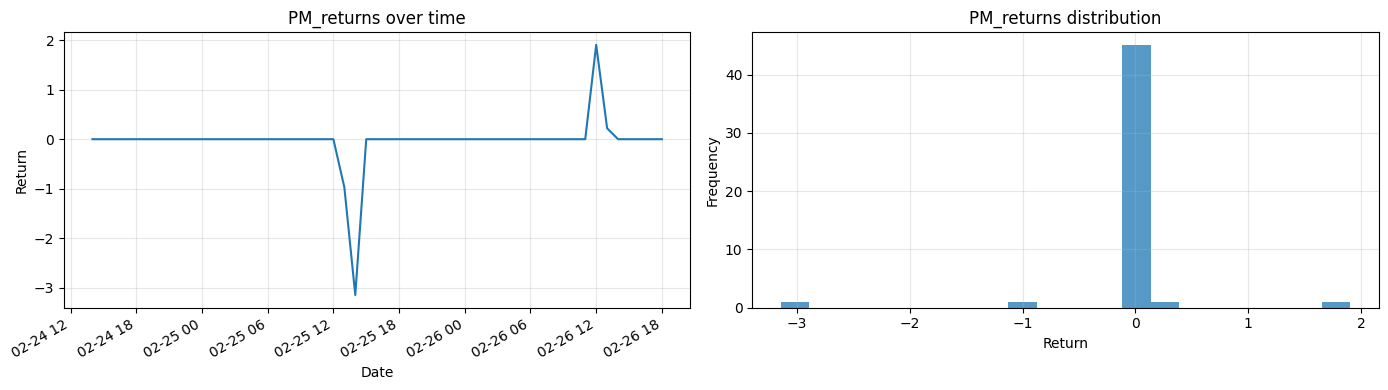

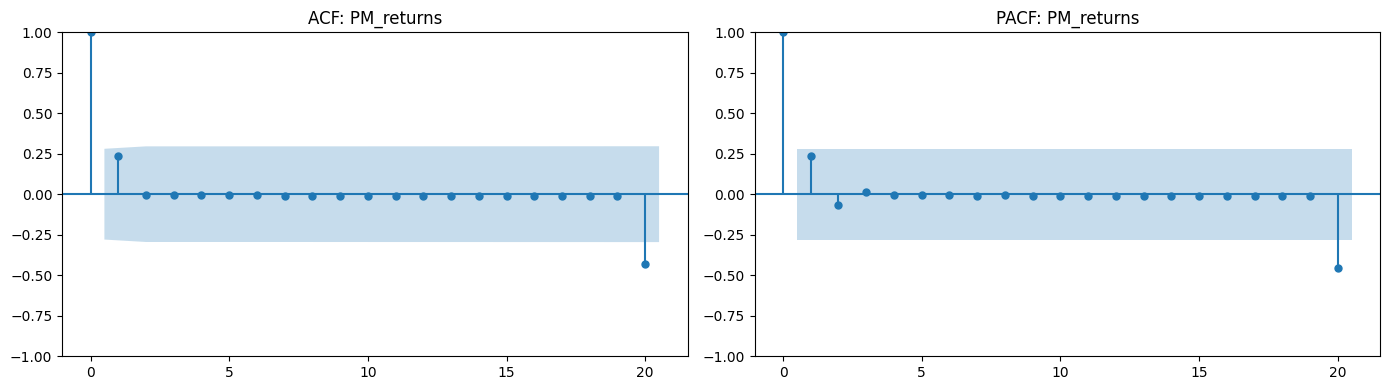

ADF statistic: -5.3402 | p-value: 0.0000
ADF conclusion (5%): Stationary
KPSS statistic: 0.1868 | p-value: 0.1000
KPSS conclusion (5%): Stationary

Series: BEL_idiosyncratic
Observations: 49


/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_94573/4262617980.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")


,mean,std,min,max,skew,kurtosis
BEL_idiosyncratic,1.558844e-15,36.092632,-79.041436,188.850724,2.980685,15.541058


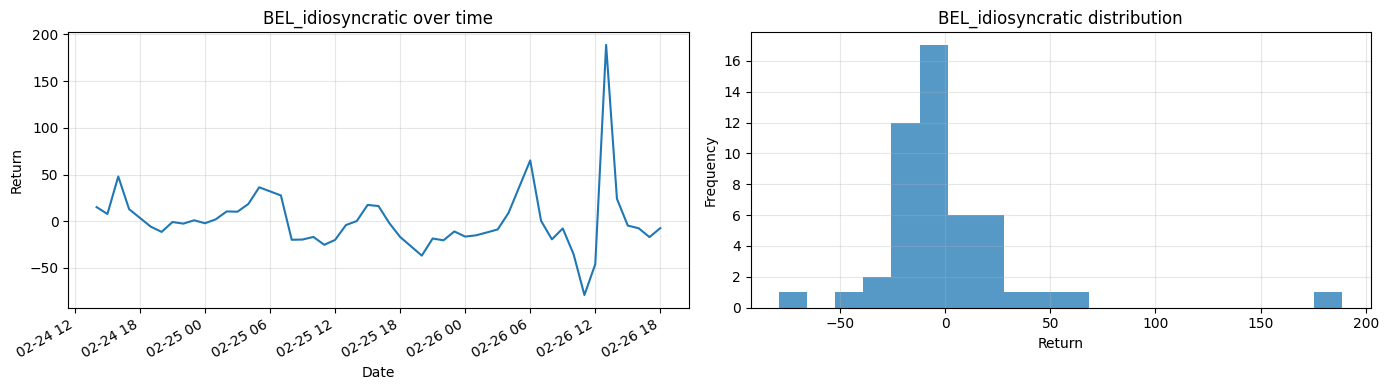

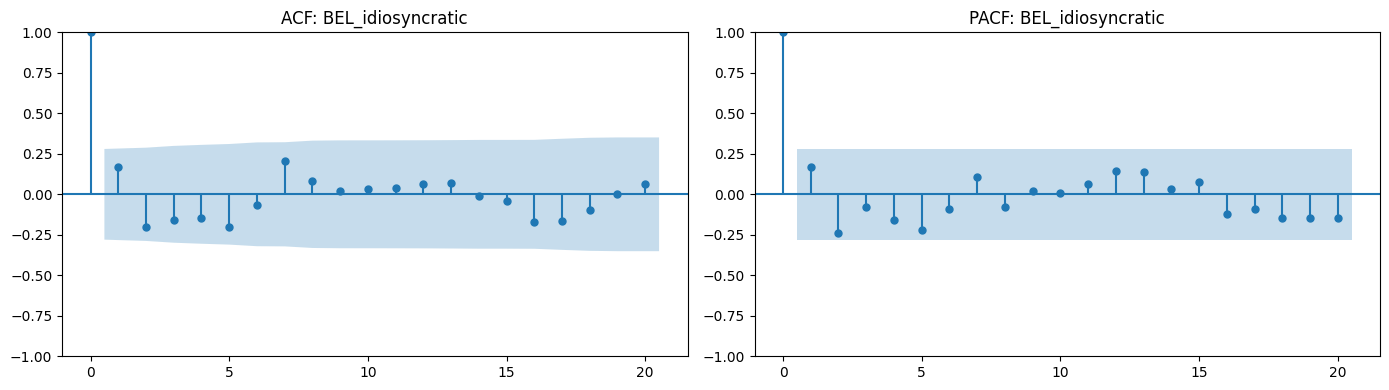

ADF statistic: -2.4897 | p-value: 0.1180
ADF conclusion (5%): Non-stationary
KPSS statistic: 0.0841 | p-value: 0.1000
KPSS conclusion (5%): Stationary



/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_94573/4262617980.py:82: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")


In [46]:
# ====================================================
# Time-series EDA: Prediction market returns and Belgian idiosyncratic returns
# Includes autocorrelation and stationarity checks
# ====================================================
import matplotlib.pyplot as plt

try:
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    statsmodels_available = True
except Exception as exc:
    statsmodels_available = False
    print("statsmodels is required for ACF/PACF and ADF/KPSS tests.")
    print("Install with: pip install statsmodels")
    print("Import error:", exc)

# Build prediction-market returns from level prices (Yes contract)
pm_returns = hourly_aligned.copy().sort_values("timestamp")
pm_returns["PM_returns"] = pm_returns["price_Yes"].pct_change() * 100

series_map = {
    "PM_returns": pm_returns.set_index("timestamp")["PM_returns"],
    "BEL_idiosyncratic": hourly_aligned.set_index("timestamp").get("BEL_idiosyncratic"),
}

if series_map["BEL_idiosyncratic"] is None:
    raise ValueError("BEL_idiosyncratic not found. Run the Belgian factor model cell first.")

for name, sr in series_map.items():
    sr = sr.dropna().copy()
    if sr.empty:
        print(f"Skipping {name}: no non-NaN observations.")
        continue

    print("=" * 70)
    print(f"Series: {name}")
    print(f"Observations: {len(sr)}")

    # Descriptive stats
    desc = pd.DataFrame({
        "mean": [sr.mean()],
        "std": [sr.std()],
        "min": [sr.min()],
        "max": [sr.max()],
        "skew": [sr.skew()],
        "kurtosis": [sr.kurt()],
    }, index=[name])
    display(desc)

    # Time-series and distribution view
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sr.plot(ax=axes[0], title=f"{name} over time")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Return")
    axes[0].grid(alpha=0.3)

    axes[1].hist(sr, bins=20, alpha=0.75)
    axes[1].set_title(f"{name} distribution")
    axes[1].set_xlabel("Return")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    if statsmodels_available and len(sr) >= 8:
        # ACF / PACF
        max_lags = min(20, max(1, len(sr) // 2 - 1))
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(sr, lags=max_lags, ax=axes[0])
        axes[0].set_title(f"ACF: {name}")
        plot_pacf(sr, lags=max_lags, ax=axes[1], method="ywm")
        axes[1].set_title(f"PACF: {name}")
        plt.tight_layout()
        plt.show()

        # Stationarity tests: ADF (H0: unit root), KPSS (H0: stationary)
        adf_stat, adf_p, *_ = adfuller(sr, autolag="AIC")
        print(f"ADF statistic: {adf_stat:.4f} | p-value: {adf_p:.4f}")
        print("ADF conclusion (5%):", "Stationary" if adf_p < 0.05 else "Non-stationary")

        try:
            kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")
            print(f"KPSS statistic: {kpss_stat:.4f} | p-value: {kpss_p:.4f}")
            print("KPSS conclusion (5%):", "Stationary" if kpss_p >= 0.05 else "Non-stationary")
        except Exception as kpss_exc:
            print("KPSS test failed:", kpss_exc)

        print()
    elif not statsmodels_available:
        print("Skipping ACF/PACF and ADF/KPSS because statsmodels is unavailable.")
    else:
        print("Skipping ACF/PACF and ADF/KPSS due to too few observations.")

In [10]:
# ====================================================
# Modeling stage: VAR, SVAR, and ML benchmark
# Target relationship: X_series -> Y_series (auto-detected)
# ====================================================

import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

# ----------------------------------------------------
# 0) Build modeling dataframe from whichever pair exists
# ----------------------------------------------------
ts_df = None
source_used = None
x_col = None
y_col = None

# Option A: direct pair in merged_inner
if "merged_inner" in globals() and isinstance(merged_inner, pd.DataFrame):
    if {"LLA_returns", "MERV_idiosyncratic"}.issubset(merged_inner.columns):
        x_col, y_col = "LLA_returns", "MERV_idiosyncratic"
        ts_df = merged_inner[[x_col, y_col]].dropna().copy()
        source_used = "merged_inner"

# Option B: direct pair in hourly_aligned
if ts_df is None and "hourly_aligned" in globals() and isinstance(hourly_aligned, pd.DataFrame):
    if {"LLA_returns", "MERV_idiosyncratic"}.issubset(hourly_aligned.columns):
        x_col, y_col = "LLA_returns", "MERV_idiosyncratic"
        ts_df = hourly_aligned[[x_col, y_col]].dropna().copy()
        source_used = "hourly_aligned"

# Option C: PM/BEL pair currently used in this notebook
if ts_df is None and "hourly_aligned" in globals() and isinstance(hourly_aligned, pd.DataFrame):
    if {"price_Yes", "BEL_idiosyncratic"}.issubset(hourly_aligned.columns):
        _tmp = hourly_aligned[["timestamp", "price_Yes", "BEL_idiosyncratic"]].copy().sort_values("timestamp")
        _tmp["PM_returns"] = _tmp["price_Yes"].pct_change() * 100
        x_col, y_col = "PM_returns", "BEL_idiosyncratic"
        ts_df = _tmp[[x_col, y_col]].dropna().copy()
        source_used = "hourly_aligned(price_Yes -> PM_returns)"

if ts_df is None:
    raise ValueError(
        "Could not find a valid modeling pair. Expected one of: "
        "(LLA_returns, MERV_idiosyncratic) or (PM_returns/BEL_idiosyncratic with price_Yes available)."
    )

# Drop DatetimeIndex frequency concerns for this modeling block
ts_df = ts_df.reset_index(drop=True)

if len(ts_df) < 40:
    raise ValueError(f"Not enough observations for robust model comparison: {len(ts_df)}")

# Time split: hold out last 5 observations
split_idx = len(ts_df) - 5
if split_idx < 20:
    raise ValueError(f"Training sample too small after 5-step holdout: train={split_idx}")
train_df = ts_df.iloc[:split_idx].copy()
val_df = ts_df.iloc[split_idx:].copy()

print(f"Source: {source_used}")
print(f"Target relationship: {x_col} -> {y_col}")
print(f"Total obs: {len(ts_df)} | Train: {len(train_df)} | Validation: {len(val_df)}")
display(ts_df.head())

def one_step_from_params(history_window, coefs, intercept):
    yhat = np.array(intercept, dtype=float).copy()
    k_ar = coefs.shape[0]
    for lag in range(1, k_ar + 1):
        yhat += coefs[lag - 1] @ history_window[-lag]
    return yhat

def rolling_forecast_multivariate_from_params(coefs, intercept, train_data, val_data):
    k_ar = coefs.shape[0]
    history = train_data.to_numpy().tolist()
    preds = []
    for i in range(len(val_data)):
        history_window = np.array(history[-k_ar:])
        yhat = one_step_from_params(history_window, coefs, intercept)
        preds.append(yhat)
        history.append(val_data.iloc[i].to_numpy())
    pred_df = pd.DataFrame(preds, index=val_data.index, columns=train_data.columns)
    return pred_df

def rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

# -----------------------------
# 1) VAR: tune lag by validation RMSE
# -----------------------------
var_candidates = []
max_lag = min(10, max(2, len(train_df) // 8))

for p in range(1, max_lag + 1):
    try:
        var_fit = VAR(train_df).fit(p)
        var_pred = rolling_forecast_multivariate_from_params(
            var_fit.coefs, var_fit.intercept, train_df, val_df
        )
        score = rmse(val_df[y_col], var_pred[y_col])
        var_candidates.append({"model": "VAR", "lag": p, "val_rmse": score, "fit": var_fit})
    except Exception as exc:
        print(f"VAR lag {p} failed: {exc}")

if not var_candidates:
    raise RuntimeError("All VAR candidates failed.")

best_var = min(var_candidates, key=lambda x: x["val_rmse"])
print(f"Best VAR lag: {best_var['lag']} | Validation RMSE: {best_var['val_rmse']:.6f}")

# -----------------------------
# 2) SVAR: A-model with X contemporaneously affecting Y
# -----------------------------
svar_candidates = []
A_template = np.array([[1, 0], ["E", 1]], dtype=object)

for p in range(1, max_lag + 1):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            svar_mod = SVAR(train_df, svar_type="A", A=A_template)
            svar_fit = svar_mod.fit(
                maxlags=p, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000
            )
        p_eff = int(svar_fit.k_ar)
        if p_eff < 1:
            continue
        svar_pred = rolling_forecast_multivariate_from_params(
            svar_fit.coefs, svar_fit.intercept, train_df, val_df
        )
        score = rmse(val_df[y_col], svar_pred[y_col])
        svar_candidates.append({"model": "SVAR", "lag": p_eff, "val_rmse": score, "fit": svar_fit})
    except Exception as exc:
        print(f"SVAR lag {p} failed: {exc}")

if svar_candidates:
    best_svar = min(svar_candidates, key=lambda x: x["val_rmse"])
    print(f"Best SVAR lag: {best_svar['lag']} | Validation RMSE: {best_svar['val_rmse']:.6f}")
else:
    best_svar = None
    print("SVAR candidates failed; check sample size or identification assumptions.")

# -----------------------------
# 3) ML benchmark: choose best model family + hyperparameters on lag features
# -----------------------------
def build_lagged_xy(df, target_col, feature_cols, n_lags):
    out = pd.DataFrame(index=df.index)
    for col in feature_cols:
        for lag in range(1, n_lags + 1):
            out[f"{col}_lag{lag}"] = df[col].shift(lag)
    out[target_col] = df[target_col]
    out = out.dropna()
    X = out.drop(columns=[target_col])
    y = out[target_col]
    return X, y

def make_estimator(model_name, params):
    if model_name == "Ridge":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=params["alpha"])),
        ])
    if model_name == "Lasso":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=params["alpha"], max_iter=20000, random_state=42)),
        ])
    if model_name == "ElasticNet":
        return Pipeline([
            ("scaler", StandardScaler()),
            (
                "model",
                ElasticNet(
                    alpha=params["alpha"],
                    l1_ratio=params["l1_ratio"],
                    max_iter=20000,
                    random_state=42,
                ),
            ),
        ])
    if model_name == "SVR":
        return Pipeline([
            ("scaler", StandardScaler()),
            (
                "model",
                SVR(
                    C=params["C"],
                    epsilon=params["epsilon"],
                    gamma=params["gamma"],
                    kernel=params["kernel"],
                ),
            ),
        ])
    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1,
        )
    if model_name == "ExtraTrees":
        return ExtraTreesRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1,
        )
    if model_name == "GradientBoosting":
        return GradientBoostingRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            random_state=42,
        )
    raise ValueError(f"Unknown model_name: {model_name}")

ml_model_space = {
    "Ridge": {"alpha": [0.01, 0.1, 1.0, 10.0]},
    "Lasso": {"alpha": [0.001, 0.01, 0.1, 1.0]},
    "ElasticNet": {"alpha": [0.001, 0.01, 0.1], "l1_ratio": [0.2, 0.5, 0.8]},
    "SVR": {
        "C": [0.5, 1.0, 5.0],
        "epsilon": [0.05, 0.1, 0.2],
        "gamma": ["scale"],
        "kernel": ["rbf", "linear"],
    },
    "RandomForest": {
        "n_estimators": [200, 500],
        "max_depth": [3, 5, None],
        "min_samples_leaf": [1, 2],
    },
    "ExtraTrees": {
        "n_estimators": [200, 500],
        "max_depth": [3, 5, None],
        "min_samples_leaf": [1, 2],
    },
    "GradientBoosting": {
        "n_estimators": [150, 300],
        "learning_rate": [0.03, 0.1],
        "max_depth": [2, 3],
    },
}

ml_candidates = []
feature_cols = [x_col, y_col]
lag_grid = [1, 2, 3, 5]

for n_lags in lag_grid:
    X_all, y_all = build_lagged_xy(ts_df, y_col, feature_cols, n_lags)
    if len(X_all) < 30:
        continue

    split_ml = len(X_all) - 5
    if split_ml < 20:
        continue

    X_train, X_val = X_all.iloc[:split_ml], X_all.iloc[split_ml:]
    y_train, y_val = y_all.iloc[:split_ml], y_all.iloc[split_ml:]

    for model_name, param_space in ml_model_space.items():
        for params in ParameterGrid(param_space):
            try:
                est = make_estimator(model_name, params)
                est.fit(X_train, y_train)
                pred = pd.Series(est.predict(X_val), index=y_val.index)
                score = rmse(y_val, pred)
                ml_candidates.append(
                    {
                        "model": model_name,
                        "lags": n_lags,
                        "params": params,
                        "val_rmse": score,
                        "fit": est,
                        "X_cols": X_train.columns.tolist(),
                    }
                )
            except Exception as exc:
                print(f"{model_name} failed (lags={n_lags}, params={params}): {exc}")

if not ml_candidates:
    raise RuntimeError("All ML candidates failed.")

best_ml = min(ml_candidates, key=lambda x: x["val_rmse"])
print(
    f"Best ML model: {best_ml['model']} | lags={best_ml['lags']} | "
    f"params={best_ml['params']} | Validation RMSE: {best_ml['val_rmse']:.6f}"
)

ml_compare = (
    pd.DataFrame(
        [
            {
                "Model": c["model"],
                "Lags": c["lags"],
                "Params": str(c["params"]),
                "Validation RMSE": c["val_rmse"],
            }
            for c in ml_candidates
        ]
    )
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)

print("Top 10 ML configurations:")
display(ml_compare.head(10))

# -----------------------------
# Model comparison table
# -----------------------------
rows = [
    {"Model": "VAR", "Best spec": f"lag={best_var['lag']}", "Validation RMSE": best_var["val_rmse"]},
    {
        "Model": "SVAR",
        "Best spec": f"lag={best_svar['lag']}" if best_svar is not None else "failed",
        "Validation RMSE": best_svar["val_rmse"] if best_svar is not None else np.nan,
    },
    {
        "Model": f"ML ({best_ml['model']})",
        "Best spec": f"lags={best_ml['lags']}, params={best_ml['params']}",
        "Validation RMSE": best_ml["val_rmse"],
    },
]

model_compare = pd.DataFrame(rows).dropna(subset=["Validation RMSE"]).sort_values("Validation RMSE").reset_index(drop=True)
print("Best-fit model ranking (lower RMSE is better):")
display(model_compare)

# Store best models/specs for downstream forecasting comparison
best_models = {
    "VAR": best_var,
    "SVAR": best_svar,
    "ML": best_ml,
    "ML_all_candidates": ml_compare,
    "x_col": x_col,
    "y_col": y_col,
    "train_df": train_df,
    "val_df": val_df,
}


Source: hourly_aligned(price_Yes -> PM_returns)
Target relationship: PM_returns -> BEL_idiosyncratic
Total obs: 49 | Train: 44 | Validation: 5


,PM_returns,BEL_idiosyncratic
0,0.0,18.778769
1,0.0,9.731400
2,0.0,41.903910
3,0.0,2.571017
4,0.0,7.898469


Best VAR lag: 1 | Validation RMSE: 21.078339
Best SVAR lag: 1 | Validation RMSE: 21.078339
Best ML model: ExtraTrees | lags=3 | params={'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 500} | Validation RMSE: 10.426333
Top 10 ML configurations:


,Model,Lags,Params,Validation RMSE
0,ExtraTrees,3,"{'max_depth': None, 'min_samples_leaf': 2, 'n_...",10.426333
1,ExtraTrees,3,"{'max_depth': None, 'min_samples_leaf': 2, 'n_...",10.773909
2,ExtraTrees,3,"{'max_depth': 5, 'min_samples_leaf': 2, 'n_est...",10.803169
3,ExtraTrees,3,"{'max_depth': 5, 'min_samples_leaf': 2, 'n_est...",11.114876
4,RandomForest,2,"{'max_depth': 3, 'min_samples_leaf': 2, 'n_est...",11.280459
5,RandomForest,2,"{'max_depth': 3, 'min_samples_leaf': 2, 'n_est...",11.317109
6,ExtraTrees,2,"{'max_depth': None, 'min_samples_leaf': 2, 'n_...",11.760216
7,ExtraTrees,3,"{'max_depth': 3, 'min_samples_leaf': 2, 'n_est...",11.933759
8,ExtraTrees,3,"{'max_depth': 3, 'min_samples_leaf': 2, 'n_est...",11.938038
9,ExtraTrees,2,"{'max_depth': None, 'min_samples_leaf': 2, 'n_...",11.940329


Best-fit model ranking (lower RMSE is better):


,Model,Best spec,Validation RMSE
0,ML (ExtraTrees),"lags=3, params={'max_depth': None, 'min_sample...",10.426333
1,VAR,lag=1,21.078339
2,SVAR,lag=1,21.078339


Simulation anchor timestamp (T-5): 2026-02-26 13:00:00+00:00
PM level at T-5 (used as probability weight): 0.2400
Electricity level at T-5: 33.600000
Forecast horizon: 5 observations

Stage-1 binomial calibration:
down node PM level: 0.2386
up node PM level:   0.2414
Best model used for scenario simulation: ML:ExtraTrees

Binomial path-level summary:


,branch,stage1,stage1_prob_node,probability,terminal_resolution,base_prob_t_minus_5,step1_prob_level,horizon_steps,terminal_abnormal_return,max_drawdown
0,down->resolve_0,down,0.238606,0.380697,0,0.24,0.238606,5,0.066531,-0.139828
1,down->resolve_1,down,0.238606,0.119303,1,0.24,0.238606,5,0.066531,-0.139828
2,up->resolve_0,up,0.241394,0.379303,0,0.24,0.241394,5,0.384483,-0.081301
3,up->resolve_1,up,0.241394,0.120697,1,0.24,0.241394,5,0.384483,-0.081301


Terminal-node summary (only two final nodes):


,terminal_resolution,terminal_label,total_probability,expected_terminal_abnormal_return,weighted_max_drawdown
0,0,Resolves to 0,0.76,0.225215,-0.110618
1,1,Resolves to 1,0.24,0.226430,-0.110394


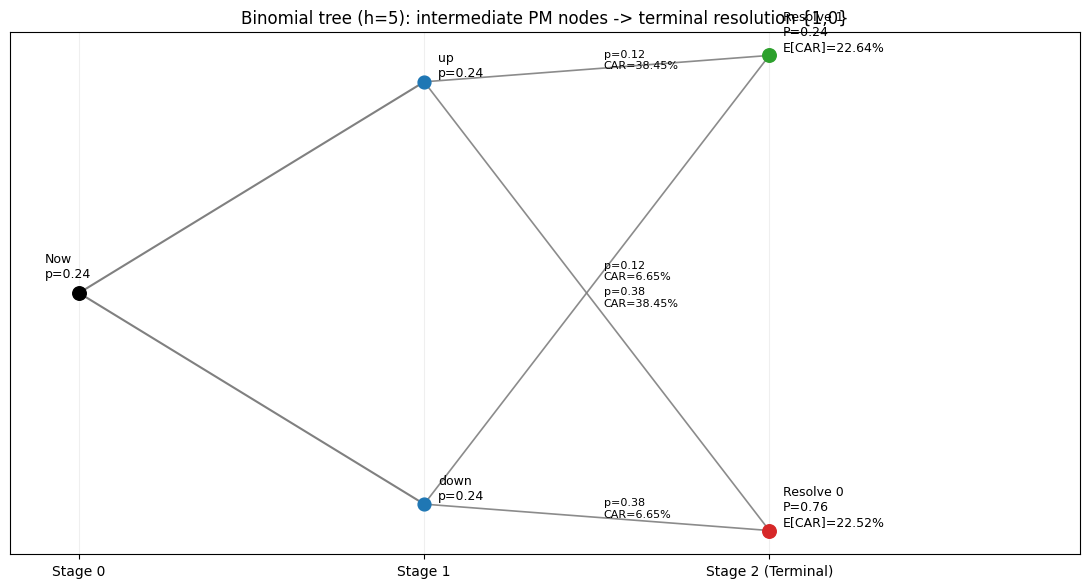

Distribution summary (path-level):


,metric,value
0,Expected terminal abnormal return,0.225507
1,5% quantile (VaR-like),0.066531
2,Expected shortfall 95%,0.066531


Total probability across all branches: 1.000000


In [49]:
# ====================================================
# Binomial tree simulation from T-5 with binary terminal resolution
# Uses prediction-market levels (price_Yes) and maps PM moves -> electricity outcomes
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

# ----------------------------------------------------
# 0) Build simulation dataset with robust column detection
# ----------------------------------------------------
pm_level_col = None
elec_level_col = None

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required for this simulation.")

for cand in ["price_Yes", "LLA (La Libertad Avanza)"]:
    if cand in hourly_aligned.columns:
        pm_level_col = cand
        break

for cand in ["Country Hourly - Belgium", "^MERV"]:
    if cand in hourly_aligned.columns:
        elec_level_col = cand
        break

if pm_level_col is None:
    raise ValueError("Could not find a PM level column (expected price_Yes or LLA-like level column).")
if elec_level_col is None:
    raise ValueError("Could not find an electricity/market level column (expected Country Hourly - Belgium or ^MERV).")

# Pull feature names from the best-model cell when available
x_ret_col = "PM_returns"
y_idio_col = "BEL_idiosyncratic"
if "best_models" in globals() and isinstance(best_models, dict):
    x_ret_col = str(best_models.get("x_col", x_ret_col))
    y_idio_col = str(best_models.get("y_col", y_idio_col))

sim_df = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)

if x_ret_col not in sim_df.columns:
    if pm_level_col in sim_df.columns:
        sim_df[x_ret_col] = sim_df[pm_level_col].pct_change() * 100
    else:
        raise ValueError(f"Missing x return column: {x_ret_col}")

need_cols = ["timestamp", pm_level_col, x_ret_col, y_idio_col, elec_level_col]
missing = [c for c in need_cols if c not in sim_df.columns]
if missing:
    raise ValueError(f"Missing required columns for simulation: {missing}")

sim_df = sim_df[need_cols].dropna().copy()

if len(sim_df) < 30:
    raise ValueError(f"Need at least 30 aligned observations for simulation; got {len(sim_df)}")

horizon = 5
if len(sim_df) <= horizon:
    raise ValueError("Not enough observations for a 5-step holdout simulation.")

# T-5 anchor (five observations before the end)
t0_pos = len(sim_df) - (horizon + 1)
t0_row = sim_df.iloc[t0_pos]
p_t0 = float(np.clip(t0_row[pm_level_col], 0.0, 1.0))
elec_t0 = float(t0_row[elec_level_col])
t0_ts = pd.Timestamp(t0_row["timestamp"])

print(f"Simulation anchor timestamp (T-5): {t0_ts}")
print(f"PM level at T-5 (used as probability weight): {p_t0:.4f}")
print(f"Electricity level at T-5: {elec_t0:.6f}")
print(f"Forecast horizon: {horizon} observations")

# Training sample strictly up to T-5
train_sim = sim_df.iloc[: t0_pos + 1][[x_ret_col, y_idio_col]].copy()
if len(train_sim) < 20:
    raise ValueError(f"Training sample too short up to T-5: {len(train_sim)}")

# ----------------------------------------------------
# Stage 1 calibration (binomial): derive two intermediate PM levels
# from empirical one-step PM-level changes centered at p_t0.
# ----------------------------------------------------
pm_hist = sim_df.iloc[: t0_pos + 1][pm_level_col].astype(float).clip(0.0, 1.0)
delta_hist = pm_hist.diff().dropna()

if delta_hist.empty:
    raise RuntimeError("Insufficient PM level history to calibrate Stage-1 binomial moves.")

q_down = float(delta_hist.quantile(0.25))
q_up = float(delta_hist.quantile(0.75))

if abs(q_up - q_down) < 1e-10:
    std_val = float(delta_hist.std(ddof=0)) if float(delta_hist.std(ddof=0)) > 0 else 1e-3
    eps = max(1e-4, std_val)
    q_down, q_up = -eps, eps

p_stage1_down = float(np.clip(p_t0 + q_down, 0.0, 1.0))
p_stage1_up = float(np.clip(p_t0 + q_up, 0.0, 1.0))

if abs(p_stage1_up - p_stage1_down) < 1e-10:
    med_abs = float(delta_hist.abs().median()) if not delta_hist.empty else 1e-3
    bump = min(0.05, max(1e-3, med_abs))
    p_stage1_down = float(np.clip(p_t0 - bump, 0.0, 1.0))
    p_stage1_up = float(np.clip(p_t0 + bump, 0.0, 1.0))

stage1_nodes = {"down": p_stage1_down, "up": p_stage1_up}
stage1_prob = {"down": 0.5, "up": 0.5}

print("\nStage-1 binomial calibration:")
print(f"down node PM level: {p_stage1_down:.4f}")
print(f"up node PM level:   {p_stage1_up:.4f}")

# ----------------------------------------------------
# Use best model from previous model-comparison cell
# ----------------------------------------------------
def choose_best_model_name():
    if "best_models" in globals() and isinstance(best_models, dict) and "ML" in best_models:
        ml_info = best_models["ML"]
        if isinstance(ml_info, dict) and "model" in ml_info:
            return f"ML:{ml_info['model']}"
    if "model_compare" in globals() and isinstance(model_compare, pd.DataFrame) and not model_compare.empty:
        return str(model_compare.iloc[0]["Model"])
    return "ML:RandomForest"

best_model_name = choose_best_model_name()
print(f"Best model used for scenario simulation: {best_model_name}")

def simulate_with_var_family(train_data, x_future_rets, use_svar=False):
    if use_svar:
        lag = 1
        if "best_models" in globals() and isinstance(best_models, dict) and best_models.get("SVAR") is not None:
            lag = int(best_models["SVAR"].get("lag", 1))
        A_template = np.array([[1, 0], ["E", 1]], dtype=object)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(train_data, svar_type="A", A=A_template)
            fit = mod.fit(maxlags=lag, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)
    else:
        lag = 1
        if "best_models" in globals() and isinstance(best_models, dict) and best_models.get("VAR") is not None:
            lag = int(best_models["VAR"].get("lag", 1))
        fit = VAR(train_data).fit(lag)

    coefs = fit.coefs
    intercept = np.array(fit.intercept, dtype=float)
    k_ar = int(coefs.shape[0])

    x_hist = train_data[x_ret_col].astype(float).tolist()
    y_hist = train_data[y_idio_col].astype(float).tolist()

    if len(x_hist) < k_ar or len(y_hist) < k_ar:
        raise RuntimeError(f"Not enough history for lag order {k_ar}.")

    preds = []
    for step in range(len(x_future_rets)):
        x_next = float(x_future_rets[step])
        y_next = float(intercept[1])
        for lag in range(1, k_ar + 1):
            A_lag = coefs[lag - 1]
            y_next += float(A_lag[1, 0]) * float(x_hist[-lag])
            y_next += float(A_lag[1, 1]) * float(y_hist[-lag])

        preds.append(y_next)
        x_hist.append(x_next)
        y_hist.append(y_next)

    return np.array(preds, dtype=float)

def build_lagged_df(df, target_col, feature_cols, n_lags):
    out = pd.DataFrame(index=df.index)
    for col in feature_cols:
        for lag in range(1, n_lags + 1):
            out[f"{col}_lag{lag}"] = df[col].shift(lag)
    out[target_col] = df[target_col]
    return out.dropna()

def make_ml_estimator(model_name, params):
    if model_name == "Ridge":
        return Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=params["alpha"]))])
    if model_name == "Lasso":
        return Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=params["alpha"], max_iter=20000, random_state=42))])
    if model_name == "ElasticNet":
        return Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(alpha=params["alpha"], l1_ratio=params["l1_ratio"], max_iter=20000, random_state=42))])
    if model_name == "SVR":
        return Pipeline([("scaler", StandardScaler()), ("model", SVR(C=params["C"], epsilon=params["epsilon"], gamma=params["gamma"], kernel=params["kernel"]))])
    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1,
        )
    if model_name == "ExtraTrees":
        return ExtraTreesRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1,
        )
    if model_name == "GradientBoosting":
        return GradientBoostingRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            random_state=42,
        )
    raise ValueError(f"Unsupported ML model for simulation: {model_name}")

def simulate_with_best_ml(train_data, x_future_rets):
    model_name = "RandomForest"
    n_lags = 3
    params = {"n_estimators": 200, "max_depth": 3, "min_samples_leaf": 2}

    if "best_models" in globals() and isinstance(best_models, dict) and "ML" in best_models:
        ml_info = best_models["ML"]
        if isinstance(ml_info, dict):
            model_name = str(ml_info.get("model", model_name))
            n_lags = int(ml_info.get("lags", n_lags))
            p = ml_info.get("params", params)
            if isinstance(p, dict):
                params = dict(p)

    feature_cols = [x_ret_col, y_idio_col]
    lagged = build_lagged_df(train_data, y_idio_col, feature_cols, n_lags)
    if len(lagged) < 15:
        raise RuntimeError(f"ML training sample too short after lagging (lags={n_lags}).")

    X_train = lagged.drop(columns=[y_idio_col])
    y_train = lagged[y_idio_col]

    model = make_ml_estimator(model_name, params)
    model.fit(X_train, y_train)

    x_hist = train_data[x_ret_col].astype(float).tolist()
    y_hist = train_data[y_idio_col].astype(float).tolist()

    if len(x_hist) < n_lags or len(y_hist) < n_lags:
        raise RuntimeError(f"Not enough history for ML lags={n_lags}.")

    preds = []
    for step in range(len(x_future_rets)):
        row = {}
        for lag in range(1, n_lags + 1):
            row[f"{x_ret_col}_lag{lag}"] = float(x_hist[-lag])
            row[f"{y_idio_col}_lag{lag}"] = float(y_hist[-lag])

        X_next = pd.DataFrame([row], columns=X_train.columns)
        y_next = float(model.predict(X_next)[0])

        preds.append(y_next)
        x_hist.append(float(x_future_rets[step]))
        y_hist.append(y_next)

    return np.array(preds, dtype=float)

def run_model_for_path(train_data, x_future_rets):
    if best_model_name == "VAR":
        return simulate_with_var_family(train_data, x_future_rets, use_svar=False)
    if best_model_name == "SVAR":
        return simulate_with_var_family(train_data, x_future_rets, use_svar=True)
    return simulate_with_best_ml(train_data, x_future_rets)

# ----------------------------------------------------
# Build binomial branches
# Terminal nodes are STRICTLY resolution = 1 or 0
# ----------------------------------------------------
def safe_return(next_level, prev_level):
    if prev_level <= 1e-12:
        return 0.0 if next_level <= 1e-12 else 1e6
    return float(next_level / prev_level - 1.0)

scenario_rows = []
path_outputs = {}

for s1_name, p1 in stage1_nodes.items():
    p1_prob = float(stage1_prob[s1_name])

    # Step 1: move from p_t0 to stage-1 PM node
    ret_step1 = safe_return(p1, p_t0) * 100.0

    for terminal in [1.0, 0.0]:
        # Final step must resolve exactly to terminal node (1 or 0)
        ret_terminal = safe_return(terminal, p1) * 100.0

        # Horizon path: step 1 move, then flat, then final resolution jump
        x_path = np.zeros(horizon, dtype=float)
        x_path[0] = ret_step1
        x_path[-1] = ret_terminal

        idio_path = run_model_for_path(train_sim, x_path)
        elec_path = elec_t0 * np.cumprod(1.0 + idio_path / 100.0)

        cond_prob = float(np.clip(p1, 0.0, 1.0)) if terminal == 1.0 else float(1.0 - np.clip(p1, 0.0, 1.0))
        joint_prob = p1_prob * cond_prob

        node_name = f"{s1_name}->resolve_{int(terminal)}"
        path_outputs[node_name] = {
            "elec_path": elec_path,
            "idio_path": idio_path,
            "x_path": x_path,
            "joint_prob": joint_prob,
            "terminal": int(terminal),
        }

        scenario_rows.append({
            "branch": node_name,
            "stage1": s1_name,
            "stage1_prob_node": p1,
            "probability": joint_prob,
            "terminal_resolution": int(terminal),
            "base_prob_t_minus_5": p_t0,
            "step1_prob_level": p1,
            "horizon_steps": horizon,
            "terminal_abnormal_return": float(elec_path[-1] / elec_t0 - 1.0),
            "max_drawdown": float((elec_path / np.maximum.accumulate(elec_path) - 1.0).min()),
        })

scenario_summary = pd.DataFrame(scenario_rows).sort_values(["stage1", "terminal_resolution"]).reset_index(drop=True)
print("\nBinomial path-level summary:")
display(scenario_summary)

terminal_summary = (
    scenario_summary
    .groupby("terminal_resolution", as_index=False)
    .apply(lambda g: pd.Series({
        "total_probability": g["probability"].sum(),
        "expected_terminal_abnormal_return": np.average(g["terminal_abnormal_return"], weights=g["probability"]) if g["probability"].sum() > 0 else np.nan,
        "weighted_max_drawdown": np.average(g["max_drawdown"], weights=g["probability"]) if g["probability"].sum() > 0 else np.nan,
    }))
    .reset_index(drop=True)
)
terminal_summary["terminal_label"] = terminal_summary["terminal_resolution"].map({1: "Resolves to 1", 0: "Resolves to 0"})
terminal_summary = terminal_summary[[
    "terminal_resolution",
    "terminal_label",
    "total_probability",
    "expected_terminal_abnormal_return",
    "weighted_max_drawdown",
]]

print("Terminal-node summary (only two final nodes):")
display(terminal_summary)

# ----------------------------------------------------
# Binomial tree plot
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

root = (0.0, 0.0)
stage1_xy = {"down": (1.0, -0.8), "up": (1.0, 0.8)}
terminal_xy = {0: (2.0, -0.9), 1: (2.0, 0.9)}

ax.scatter([root[0]], [root[1]], s=95, c="black", zorder=5)
ax.text(root[0] - 0.10, root[1] + 0.06, f"Now\np={p_t0:.2f}", fontsize=9)

for s1_name, (x1, y1) in stage1_xy.items():
    p1 = stage1_nodes[s1_name]
    ax.plot([root[0], x1], [root[1], y1], color="gray", linewidth=1.5)
    ax.scatter([x1], [y1], s=85, c="tab:blue", zorder=5)
    ax.text(x1 + 0.04, y1 + 0.02, f"{s1_name}\np={p1:.2f}", fontsize=9)

for s1_name, (x1, y1) in stage1_xy.items():
    for terminal, (x2, y2) in terminal_xy.items():
        path_key = f"{s1_name}->resolve_{terminal}"
        p_joint = path_outputs[path_key]["joint_prob"]
        car = float(path_outputs[path_key]["elec_path"][-1] / elec_t0 - 1.0)

        ax.plot([x1, x2], [y1, y2], color="tab:gray", linewidth=1.2, alpha=0.9)
        ax.text((x1 + x2) / 2 + 0.02, (y1 + y2) / 2, f"p={p_joint:.2f}\nCAR={car:.2%}", fontsize=8)

for terminal, (x2, y2) in terminal_xy.items():
    p_total = float(terminal_summary.loc[terminal_summary["terminal_resolution"] == terminal, "total_probability"].sum())
    exp_ret = float(terminal_summary.loc[terminal_summary["terminal_resolution"] == terminal, "expected_terminal_abnormal_return"].iloc[0])

    color = "tab:green" if terminal == 1 else "tab:red"
    ax.scatter([x2], [y2], s=95, c=color, zorder=6)
    ax.text(x2 + 0.04, y2 + 0.02, f"Resolve {terminal}\nP={p_total:.2f}\nE[CAR]={exp_ret:.2%}", fontsize=9)

ax.set_title(f"Binomial tree (h={horizon}): intermediate PM nodes -> terminal resolution {{1,0}}")
ax.set_xlim(-0.2, 2.9)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Stage 0", "Stage 1", "Stage 2 (Terminal)"])
ax.set_yticks([])
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

# Distribution summary across all path branches
w = scenario_summary["probability"].to_numpy()
r = scenario_summary["terminal_abnormal_return"].to_numpy()
expected_terminal = float(np.sum(w * r))
var95 = float(np.quantile(r, 0.05))
es95 = float(r[r <= var95].mean()) if np.any(r <= var95) else var95

scenario_stats = pd.DataFrame({
    "metric": ["Expected terminal abnormal return", "5% quantile (VaR-like)", "Expected shortfall 95%"],
    "value": [expected_terminal, var95, es95],
})
print("Distribution summary (path-level):")
display(scenario_stats)

prob_check = float(scenario_summary["probability"].sum())
print(f"Total probability across all branches: {prob_check:.6f}")

# Keep outputs in memory for downstream use
binomial_scenario_summary = scenario_summary
binomial_terminal_summary = terminal_summary
binomial_stats = scenario_stats


In [50]:
# ====================================================
# Proposal-aligned hedge sizing with positive-branch handling
# Consumes scenario_summary from the PM->electricity binomial simulation
# ====================================================

portfolio_value = 1_000_000
risk_budget_fraction = 0.015
execution_haircut = 0.70
hedge_efficiency = 0.60  # conservative payoff efficiency after costs/slippage

# Exposure convention:
# - "short_price": rising electricity prices are adverse (typical buyer/procurement view)
# - "long_price": falling electricity prices are adverse (producer/merchant view)
exposure_to_price = "short_price"

if "scenario_summary" not in globals() or scenario_summary.empty:
    raise ValueError("scenario_summary is missing or empty. Run the binomial simulation cell first.")

hedge_table = scenario_summary.copy()

# Ensure terminal electricity level is available for each branch
if "terminal_electricity_level" not in hedge_table.columns:
    if "path_outputs" in globals() and isinstance(path_outputs, dict):
        hedge_table["terminal_electricity_level"] = hedge_table["branch"].map(
            lambda b: float(path_outputs[b]["elec_path"][-1]) if b in path_outputs else np.nan
        )
    else:
        hedge_table["terminal_electricity_level"] = np.nan

# Keep compatibility with prior tree formats
if "year_shift" not in hedge_table.columns:
    hedge_table["year_shift"] = np.nan
if "horizon_days" not in hedge_table.columns and "horizon_steps" in hedge_table.columns:
    hedge_table["horizon_days"] = hedge_table["horizon_steps"]

ret = hedge_table["terminal_abnormal_return"].to_numpy(dtype=float)
w = hedge_table["probability"].to_numpy(dtype=float)

if exposure_to_price == "short_price":
    # Adverse outcome is electricity price increase
    loss = np.maximum(ret, 0.0)
elif exposure_to_price == "long_price":
    # Adverse outcome is electricity price decline
    loss = np.maximum(-ret, 0.0)
else:
    raise ValueError("exposure_to_price must be 'short_price' or 'long_price'.")

weighted_loss = float(np.sum(w * loss))

# Hedge only the loss in excess of the risk budget
if weighted_loss <= risk_budget_fraction:
    target_coverage = 0.0
else:
    target_coverage = (weighted_loss - risk_budget_fraction) / weighted_loss

raw_hedge_notional_pct = target_coverage / hedge_efficiency if hedge_efficiency > 0 else 0.0
hedge_notional_pct = float(np.clip(raw_hedge_notional_pct * execution_haircut, 0.0, 0.80))
hedge_notional_usd = hedge_notional_pct * portfolio_value

def hedge_instrument_mix(terminal_ret: float, side: str) -> str:
    if side == "short_price":
        # Buyer: higher prices hurt, so hedge upside in power prices
        if terminal_ret <= 0:
            return "No upside power-price hedge required; keep optional flexibility."
        if terminal_ret < 0.02:
            return "Light hedge: staged baseload futures/swaps for near delivery window."
        if terminal_ret < 0.05:
            return "Medium hedge: layered fixed-price forwards + upside cap structure."
        return "Strong hedge: high hedge ratio via strips/swaps plus call-option caps."

    # Seller/producer: lower prices hurt, so hedge downside in power prices
    if terminal_ret >= 0:
        return "No downside power-price hedge required; keep upside participation."
    if terminal_ret > -0.02:
        return "Light hedge: modest floor via put spread or fixed-price tranche."
    if terminal_ret > -0.05:
        return "Medium hedge: protective floor/collar with staged execution."
    return "Strong hedge: high floor coverage + partial de-risking of merchant exposure."

hedge_table["recommended_hedge_structure"] = hedge_table["terminal_abnormal_return"].apply(
    lambda x: hedge_instrument_mix(float(x), exposure_to_price)
)
hedge_table["suggested_hedge_notional_pct_of_exposure"] = hedge_notional_pct
hedge_table["suggested_hedge_notional_usd"] = hedge_notional_usd

display_cols = [
    "branch",
    "stage1",
    "probability",
    "year_shift",
    "horizon_days",
    "terminal_resolution",
    "terminal_electricity_level",
    "terminal_abnormal_return",
    "max_drawdown",
    "recommended_hedge_structure",
    "suggested_hedge_notional_pct_of_exposure",
    "suggested_hedge_notional_usd",
]

print(f"Exposure mode: {exposure_to_price}")
display(hedge_table[display_cols])

hedge_policy = pd.DataFrame(
    {
        "parameter": [
            "portfolio_value",
            "exposure_to_price",
            "risk_budget_fraction",
            "execution_haircut",
            "hedge_efficiency",
            "weighted_loss",
            "target_coverage",
            "final_hedge_notional_pct",
            "final_hedge_notional_usd",
        ],
        "value": [
            portfolio_value,
            exposure_to_price,
            risk_budget_fraction,
            execution_haircut,
            hedge_efficiency,
            weighted_loss,
            target_coverage,
            hedge_notional_pct,
            hedge_notional_usd,
        ],
    }
)

display(hedge_policy)
print("Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.")

# Persist outputs for downstream cells
hedge_recommendation_table = hedge_table
hedge_policy_table = hedge_policy


Exposure mode: short_price


,branch,stage1,probability,year_shift,horizon_days,terminal_resolution,terminal_electricity_level,terminal_abnormal_return,max_drawdown,recommended_hedge_structure,suggested_hedge_notional_pct_of_exposure,suggested_hedge_notional_usd
0,down->resolve_0,down,0.380697,NaN,5,0,35.835434,0.066531,-0.139828,Strong hedge: high hedge ratio via strips/swap...,0.8,800000.0
1,down->resolve_1,down,0.119303,NaN,5,1,35.835434,0.066531,-0.139828,Strong hedge: high hedge ratio via strips/swap...,0.8,800000.0
2,up->resolve_0,up,0.379303,NaN,5,0,46.518632,0.384483,-0.081301,Strong hedge: high hedge ratio via strips/swap...,0.8,800000.0
3,up->resolve_1,up,0.120697,NaN,5,1,46.518632,0.384483,-0.081301,Strong hedge: high hedge ratio via strips/swap...,0.8,800000.0


,parameter,value
0,portfolio_value,1000000
1,exposure_to_price,short_price
2,risk_budget_fraction,0.015
3,execution_haircut,0.7
4,hedge_efficiency,0.6
5,weighted_loss,0.225507
6,target_coverage,0.933483
7,final_hedge_notional_pct,0.8
8,final_hedge_notional_usd,800000.0


Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.


In [ ]:
# ====================================================
# Monte Carlo: electricity idiosyncratic returns under terminal PM resolution {0, 1}
# Adapted for smaller datasets with automatic horizon adjustment
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Config
n_sims = 5000
seed = 42
rng = np.random.default_rng(seed)

required_vars = [
    "sim_df",
    "train_sim",
    "p_t0",
    "elec_t0",
    "pm_level_col",
    "y_idio_col",
    "x_ret_col",
    "horizon",
    "t0_pos",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(
        f"Missing required variables from binomial simulation: {missing_vars}. "
        "Run the 'Binomial tree simulation' cell first."
    )

# Prepare simulation dataframe
sim_df_mc = sim_df[[pm_level_col, x_ret_col, y_idio_col]].copy().dropna()

# Adapt horizon to dataset size (need at least 8 observations for training + 2 for testing)
min_required = 10
if len(sim_df_mc) < min_required:
    adjusted_horizon = int(max(2, len(sim_df_mc) - 8))
    print(
        f"Dataset has {len(sim_df_mc)} observations. "
        f"Adapting horizon from {horizon} to {adjusted_horizon}."
    )
    horizon = adjusted_horizon
else:
    horizon = min(horizon, len(sim_df_mc) - 8)

if len(sim_df_mc) <= horizon + 8:
    raise ValueError(
        f"Insufficient aligned observations for Monte Carlo after adjustment. "
        f"Need > {horizon + 8}, got {len(sim_df_mc)}"
    )

# Training sample: up to T-{horizon+1} anchor
t0_pos_mc = len(sim_df_mc) - (horizon + 1)
train_mc = sim_df_mc.iloc[:t0_pos_mc][[x_ret_col, y_idio_col]].copy()

print(f"Anchor PM probability at T-{horizon+1}: {p_t0:.4f}")
print(f"Anchor electricity level at T-{horizon+1}: {elec_t0:.6f}")
print(f"Training rows: {len(train_mc)}")
print(f"Monte Carlo simulations: {n_sims} with horizon={horizon}")

# ====================================================
# Train sensitivity model with adaptive lag selection
# ====================================================

def build_lagged_df_mc(df, target_col, feature_cols, n_lags):
    out = pd.DataFrame(index=df.index)
    for col in feature_cols:
        for lag in range(1, n_lags + 1):
            out[f"{col}_lag{lag}"] = df[col].shift(lag)
    out[target_col] = df[target_col]
    return out.dropna().copy()

# Determine appropriate lag count based on training data size
n_lags = max(1, min(3, len(train_mc) // 5))
rf_params = {
    "n_estimators": 100,
    "max_depth": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
}

feature_cols = [x_ret_col, y_idio_col]
lagged = build_lagged_df_mc(train_mc, y_idio_col, feature_cols, n_lags)

if len(lagged) < 2:
    print(
        f"Insufficient lagged observations ({len(lagged)}). "
        f"Using simple random regression."
    )
    # Fallback: use original train data without lags
    lagged = train_mc.copy()
    lagged[y_idio_col] = train_mc[y_idio_col]
    n_lags = 0

X_train = lagged.drop(columns=[y_idio_col])
y_train = lagged[y_idio_col]

rf_model = RandomForestRegressor(random_state=seed, n_jobs=-1, **rf_params)
rf_model.fit(X_train, y_train)
rf_model.set_params(n_jobs=1)

print(f"RF setup: n_lags={n_lags}, training_size={len(lagged)}, params={rf_params}")

# ====================================================
# Simulate PM paths with forced terminal resolution {0, 1}
# ====================================================

pm_hist_levels = (
    sim_df_mc.iloc[:t0_pos_mc + 1][pm_level_col].astype(float).clip(0.0, 1.0)
)
delta_hist = pm_hist_levels.diff().dropna().to_numpy()
if len(delta_hist) == 0:
    raise RuntimeError("Insufficient PM level history to simulate paths.")

# Terminal resolution based on anchor probability
terminal_is_one = rng.random(n_sims) < p_t0
terminal_vals = np.where(terminal_is_one, 1.0, 0.0)
n_terminal_1 = int(terminal_is_one.sum())
n_terminal_0 = int(n_sims - n_terminal_1)

print(
    f"Simulated terminal counts from p={p_t0:.4f}: "
    f"resolve=1 -> {n_terminal_1}, resolve=0 -> {n_terminal_0}"
)

# Levels shape: (n_sims, horizon+1)
levels = np.empty((n_sims, horizon + 1), dtype=float)
levels[:, 0] = p_t0

for t in range(1, horizon):
    step = rng.choice(delta_hist, size=n_sims, replace=True)
    levels[:, t] = np.clip(levels[:, t - 1] + step, 0.0, 1.0)

# Force terminal state at final node
levels[:, -1] = terminal_vals

# Compute PM returns from level changes
prev = levels[:, :-1]
curr = levels[:, 1:]
pm_ret_paths = np.where(
    prev <= 1e-12,
    np.where(curr <= 1e-12, 0.0, 1e3),
    curr / prev - 1.0,
)

# ====================================================
# Batched recursive simulation for electricity idiosyncratic returns
# ====================================================

if n_lags == 0:
    # Fallback for very small datasets: use simple mean residual prediction
    last_pm = np.array([0.0])
    last_elec = np.array([train_mc[y_idio_col].mean()])
    idio_paths = np.random.normal(
        loc=last_elec,
        scale=train_mc[y_idio_col].std(ddof=1) + 1e-6,
        size=(n_sims, horizon),
    )
    print("Using fallback simple random prediction due to insufficient training data.")
else:
    last_pm = train_mc[x_ret_col].astype(float).to_numpy()[-n_lags:]
    last_elec = train_mc[y_idio_col].astype(float).to_numpy()[-n_lags:]

    if len(last_pm) < n_lags or len(last_elec) < n_lags:
        raise RuntimeError("Not enough history for recursive simulation.")

    # Each row = one simulation path
    pm_hist = np.tile(last_pm, (n_sims, 1)) if n_lags > 0 else np.zeros((n_sims, 1))
    elec_hist = np.tile(last_elec, (n_sims, 1)) if n_lags > 0 else np.full(
        (n_sims, 1), last_elec[0]
    )

    idio_paths = np.empty((n_sims, horizon), dtype=float)

    # Pre-parse feature column mapping
    col_map = []
    for col in X_train.columns:
        if col.startswith(f"{x_ret_col}_lag"):
            lag = int(col.replace(f"{x_ret_col}_lag", ""))
            col_map.append(("pm", lag))
        elif col.startswith(f"{y_idio_col}_lag"):
            lag = int(col.replace(f"{y_idio_col}_lag", ""))
            col_map.append(("elec", lag))
        elif col == x_ret_col:
            col_map.append(("pm", 0))
        elif col == y_idio_col:
            col_map.append(("elec", 0))

    for step in range(horizon):
        X_step = np.empty((n_sims, len(col_map)), dtype=float)
        for j, (kind, lag) in enumerate(col_map):
            if lag == 0:
                # Current value (not lagged) - use most recent or zero
                X_step[:, j] = 0.0 if step == 0 else (
                    pm_ret_paths[:, step - 1]
                    if kind == "pm"
                    else idio_paths[:, step - 1]
                )
            else:
                idx = n_lags - lag
                X_step[:, j] = (
                    pm_hist[:, idx] if kind == "pm" else elec_hist[:, idx]
                )

        X_step_df = pd.DataFrame(X_step, columns=X_train.columns)
        elec_next = rf_model.predict(X_step_df).astype(float)

        idio_paths[:, step] = elec_next

        # Roll histories forward
        if n_lags > 0:
            pm_hist[:, :-1] = pm_hist[:, 1:]
            elec_hist[:, :-1] = elec_hist[:, 1:]
            pm_hist[:, -1] = pm_ret_paths[:, step]
            elec_hist[:, -1] = elec_next

# ====================================================
# Aggregate outputs (vectorized)
# ====================================================

wealth = np.cumprod(1.0 + idio_paths / 100.0, axis=1)
cum_elec_idio_return = (wealth[:, -1] - 1.0) * 100.0
peak = np.maximum.accumulate(wealth, axis=1)
max_drawdown = np.min(wealth / peak - 1.0, axis=1) * 100.0
mean_daily_idio = np.mean(idio_paths, axis=1)
std_daily_idio = np.std(idio_paths, axis=1, ddof=0)

mc_results = pd.DataFrame(
    {
        "sim_id": np.arange(n_sims, dtype=int),
        "terminal_resolution": terminal_vals.astype(int),
        "cum_elec_idio_return_pct": cum_elec_idio_return.astype(float),
        "mean_daily_idio_pct": mean_daily_idio.astype(float),
        "std_daily_idio_pct": std_daily_idio.astype(float),
        "max_drawdown_pct": max_drawdown.astype(float),
    }
)

# Summary statistics by terminal resolution
def q05(x):
    return float(np.quantile(x, 0.05))

def q50(x):
    return float(np.quantile(x, 0.50))

def q95(x):
    return float(np.quantile(x, 0.95))

summary_by_terminal = (
    mc_results.groupby("terminal_resolution", as_index=False)
    .agg(
        n_sims=("sim_id", "count"),
        mean_cum_idio_pct=("cum_elec_idio_return_pct", "mean"),
        std_cum_idio_pct=("cum_elec_idio_return_pct", "std"),
        q05_cum_idio_pct=("cum_elec_idio_return_pct", q05),
        median_cum_idio_pct=("cum_elec_idio_return_pct", q50),
        q95_cum_idio_pct=("cum_elec_idio_return_pct", q95),
        mean_max_drawdown_pct=("max_drawdown_pct", "mean"),
    )
    .sort_values("terminal_resolution", ascending=False)
    .reset_index(drop=True)
)
summary_by_terminal["terminal_label"] = summary_by_terminal["terminal_resolution"].map(
    {1: "Resolves to 1", 0: "Resolves to 0"}
)
summary_by_terminal = summary_by_terminal[
    [
        "terminal_resolution",
        "terminal_label",
        "n_sims",
        "mean_cum_idio_pct",
        "std_cum_idio_pct",
        "q05_cum_idio_pct",
        "median_cum_idio_pct",
        "q95_cum_idio_pct",
        "mean_max_drawdown_pct",
    ]
]

overall = pd.DataFrame(
    {
        "metric": [
            "Current PM probability at anchor",
            "Total simulations",
            "Share terminal=1",
            "Share terminal=0",
            "Overall mean cumulative energy idio return (%)",
        ],
        "value": [
            p_t0,
            n_sims,
            n_terminal_1 / n_sims,
            n_terminal_0 / n_sims,
            float(mc_results["cum_elec_idio_return_pct"].mean()),
        ],
    }
)

print("Monte Carlo summary of electricity idiosyncratic outcomes by terminal PM resolution:")
display(summary_by_terminal)
print("\nOverall simulation stats:")
display(overall)

# Distribution histogram
fig, ax = plt.subplots(figsize=(11, 5))
for term, color, label in [
    (1, "tab:green", "Terminal=1 (PM resolves Yes)"),
    (0, "tab:red", "Terminal=0 (PM resolves No)"),
]:
    vals = mc_results.loc[
        mc_results["terminal_resolution"] == term, "cum_elec_idio_return_pct"
    ]
    ax.hist(
        vals,
        bins=45,
        alpha=0.50,
        density=True,
        color=color,
        label=f"{label} (n={len(vals)})",
    )

ax.set_title(
    "Monte Carlo distribution: cumulative electricity idiosyncratic return by terminal PM resolution",
    fontsize=12,
)
ax.set_xlabel("Cumulative idiosyncratic return (%)", fontsize=11)
ax.set_ylabel("Probability density", fontsize=11)
ax.axvline(0, color="gray", linewidth=1.2, linestyle="--", alpha=0.7)
ax.grid(alpha=0.25)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Expose outputs for downstream use
mc_elec_idio_results = mc_results
mc_elec_idio_summary = summary_by_terminal


In [ ]:
# ====================================================
# Monte Carlo branching visualization with conditional prediction intervals
# Anchor-normalized cumulative electricity idiosyncratic returns by terminal PM state
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_mc_vars = [
    "idio_paths",
    "terminal_vals",
    "sim_df_mc",
    "t0_pos",
    "horizon",
    "y_idio_col",
]
missing_mc_vars = [v for v in required_mc_vars if v not in globals()]
if missing_mc_vars:
    raise ValueError(
        f"Missing variables from Monte Carlo cell: {missing_mc_vars}. "
        "Run the 'Monte Carlo' cell first."
    )

# Historical idiosyncratic returns up to anchor
hist_idio = sim_df_mc.iloc[:t0_pos + 1][y_idio_col].dropna().astype(float)
if hist_idio.empty:
    raise ValueError(
        f"Historical {y_idio_col} series is empty up to anchor."
    )

# Keep short recent context and normalize so anchor = 0
pre_hist = min(6, len(hist_idio))
hist_tail = hist_idio.tail(pre_hist).to_numpy()
hist_cum = np.cumsum(hist_tail)
hist_rel = hist_cum - hist_cum[-1]
hist_x = np.arange(-len(hist_rel) + 1, 1)

# Monte Carlo cumulative paths by terminal condition (in %, anchor at 0)
cum_paths_pp = np.cumsum(idio_paths, axis=1)
mask_resolve_1 = terminal_vals.astype(int) == 1
mask_resolve_0 = terminal_vals.astype(int) == 0

if mask_resolve_1.sum() == 0 or mask_resolve_0.sum() == 0:
    raise ValueError(
        "Need at least one path in each terminal state to draw branching visualization."
    )

# Compute conditional quantiles
res1_mean = cum_paths_pp[mask_resolve_1].mean(axis=0)
res1_lo = np.quantile(cum_paths_pp[mask_resolve_1], 0.10, axis=0)
res1_hi = np.quantile(cum_paths_pp[mask_resolve_1], 0.90, axis=0)

res0_mean = cum_paths_pp[mask_resolve_0].mean(axis=0)
res0_lo = np.quantile(cum_paths_pp[mask_resolve_0], 0.10, axis=0)
res0_hi = np.quantile(cum_paths_pp[mask_resolve_0], 0.90, axis=0)

future_x = np.arange(1, int(horizon) + 1)

# Create branching plot
fig, ax = plt.subplots(figsize=(13, 6))

# Historical pre-branch path (black)
ax.plot(hist_x, hist_rel, color="black", lw=2.4, zorder=5)
ax.scatter([0], [0.0], color="black", s=38, zorder=6)

# Terminal=0 branch (draw first so not hidden)
ax.plot(future_x, res0_mean, color="red", lw=2.3, ls="--", zorder=2)
ax.fill_between(future_x, res0_lo, res0_hi, color="red", alpha=0.16, zorder=1)

# Terminal=1 branch (draw second for visibility)
ax.plot(future_x, res1_mean, color="green", lw=2.8, zorder=4)
ax.fill_between(future_x, res1_lo, res1_hi, color="green", alpha=0.16, zorder=3)

# Branching divider
ax.axvline(0, color="gray", lw=1.0, alpha=0.55)

# Right-side labels with collision avoidance
label_x = future_x[-1] + 0.8
res1_y = float(res1_mean[-1])
res0_y = float(res0_mean[-1])
if abs(res1_y - res0_y) < 0.45:
    res1_y += 0.35
    res0_y -= 0.35

ax.text(
    label_x,
    res1_y,
    "Electricity idiosyncratic path if PM resolves to 1",
    color="green",
    fontsize=12,
    va="center",
)
ax.text(
    label_x,
    res0_y,
    "Electricity idiosyncratic path if PM resolves to 0",
    color="red",
    fontsize=12,
    va="center",
)

# Set axis limits with padding
y_vals = np.concatenate(
    [hist_rel, res1_lo, res1_hi, res0_lo, res0_hi, np.array([0.0])]
)
y_pad = max(0.5, 0.10 * (y_vals.max() - y_vals.min() + 1e-9))
ax.set_xlim(hist_x[0] - 0.4, label_x + 0.8)
ax.set_ylim(y_vals.min() - y_pad, y_vals.max() + y_pad)

ax.set_title(
    "Branching simulation with terminal PM resolution and prediction intervals",
    fontsize=13,
)
ax.set_xlabel("Time (anchor at 0)", fontsize=11)
ax.set_ylabel(
    f"Cumulative {y_idio_col} return (%, anchor-normalized)",
    fontsize=11,
)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Monte Carlo branching paths displayed.")
print(f"Green band: terminal PM resolution = 1 (Yes)")
print(f"Red band: terminal PM resolution = 0 (No)")
print(f"Bands represent 10th-90th percentile across {n_sims} simulations")


In [11]:
# Compare factor-model explanatory power: weather-only vs weather+load
import numpy as np
import pandas as pd

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required. Run the aligned dataset and factor-model cells first.")

base_target = "Country Hourly - Belgium"
weather_cols = ["BE Temp (C)", "BE Precipitation (mm)", "BE Wind Speed (km/h)"]
load_cols = ["pct_BE_actual_load", "pct_BE_forecast_load", "pct_BE_forecast_vs_actual_load"]

missing_weather = [c for c in weather_cols + [base_target] if c not in hourly_aligned.columns]
if missing_weather:
    raise ValueError(f"Missing weather/target columns in hourly_aligned: {missing_weather}")

def fit_pca_factor_model(df, target_col, factor_cols, label):
    work = df[["timestamp", target_col] + factor_cols].copy().sort_values("timestamp").reset_index(drop=True)
    work[factor_cols + [target_col]] = work[factor_cols + [target_col]].interpolate(method="linear", limit_area="inside")
    work["BEL_returns"] = work[target_col].pct_change() * 100
    ret_df = work[["timestamp", "BEL_returns"] + factor_cols].dropna().copy()

    if len(ret_df) < 5:
        return {"label": label, "n_obs": len(ret_df), "error": "too_few_rows"}

    std = ret_df[factor_cols].std(axis=0, ddof=0)
    active = std[std > 0].index.tolist()
    if not active:
        return {"label": label, "n_obs": len(ret_df), "error": "no_active_factors"}

    X = ret_df[active]
    y = ret_df["BEL_returns"]
    Xz = ((X - X.mean(axis=0)) / X.std(axis=0, ddof=0)).dropna().copy()
    y = y.loc[Xz.index]

    U, S, _ = np.linalg.svd(Xz.to_numpy(), full_matrices=False)
    explained = (S**2) / np.sum(S**2)
    n_components = max(1, int(np.searchsorted(np.cumsum(explained), 0.95) + 1))
    scores = U * S
    X_pca = scores[:, :n_components]

    X_design = np.column_stack([np.ones(len(X_pca)), X_pca])
    coef = np.linalg.lstsq(X_design, y.to_numpy(), rcond=None)[0]
    fitted = X_design @ coef
    resid = y.to_numpy() - fitted

    rss = float(np.sum(resid**2))
    tss = float(np.sum((y.to_numpy() - y.mean())**2))
    r2 = float(1 - rss / tss) if tss > 0 else float("nan")
    n = len(y)
    k = n_components
    adj_r2 = float(1 - (1 - r2) * (n - 1) / (n - k - 1)) if n > (k + 1) else float("nan")

    return {
        "label": label,
        "n_obs": int(n),
        "n_active_factors": int(len(active)),
        "n_components": int(n_components),
        "r2": r2,
        "adj_r2": adj_r2,
        "resid_std": float(np.std(resid, ddof=1)) if n > 1 else float("nan"),
        "active_factors": active,
    }

results = []
results.append(fit_pca_factor_model(hourly_aligned, base_target, weather_cols, "Weather only"))

available_load_cols = [c for c in load_cols if c in hourly_aligned.columns]
if len(available_load_cols) == len(load_cols):
    results.append(
        fit_pca_factor_model(
            hourly_aligned,
            base_target,
            weather_cols + load_cols,
            "Weather + load factors",
        )
    )
else:
    print("Skipping weather+load comparison because load factors are missing:", [c for c in load_cols if c not in hourly_aligned.columns])

comp = pd.DataFrame([{k: v for k, v in r.items() if k != "active_factors"} for r in results])
display(comp)

for r in results:
    print("\n", r["label"], sep="")
    if "error" in r:
        print("Error:", r["error"])
        continue
    print("Active factors:", r["active_factors"])
    print(f"R2: {r['r2']:.4f} | Adj R2: {r['adj_r2']:.4f} | Residual std: {r['resid_std']:.4f}")

,label,n_obs,n_active_factors,n_components,r2,adj_r2,resid_std
0,Weather only,49,2,2,0.110590,0.071920,36.092632
1,Weather + load factors,49,5,4,0.170734,0.095347,34.850937



Weather only
Active factors: ['BE Temp (C)', 'BE Wind Speed (km/h)']
R2: 0.1106 | Adj R2: 0.0719 | Residual std: 36.0926

Weather + load factors
Active factors: ['BE Temp (C)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
R2: 0.1707 | Adj R2: 0.0953 | Residual std: 34.8509
